# Importing necesaary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting a consistent tone for our visualisation

In [2]:
# --- Set a consistent dark-theme style for all charts ---
# These settings apply globally to every chart created after this point
plt.rcParams.update({
    'figure.facecolor': '#0f0f14',   # dark background for the whole figure
    'axes.facecolor':   '#0f0f14',   # dark background inside the chart area
    'axes.edgecolor':   '#2a2a3a',   # subtle border around the chart
    'axes.labelcolor':  '#c8c4b8',   # axis label text colour
    'text.color':       '#c8c4b8',   # general text colour
    'xtick.color':      '#666680',   # x-axis tick marks
    'ytick.color':      '#666680',   # y-axis tick marks
    'grid.color':       '#1e1e2e',   # light grid lines
    'grid.linewidth':   0.5,
    'font.family':      'monospace',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.titlecolor':  '#e0dcd4',
    'figure.titlesize': 15,
})

# A shared colour palette — we use the same colours throughout all charts
# so the notebook looks consistent and professional
ACCENT = ['#d4e832', '#e8622a', '#18c9a0', '#a66ef5', '#3ba9e8', '#f5a623', '#e84393']


# Loading cleaned dataset from drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
file_path = '/content/drive/MyDrive/Sales Retail Dataset/retail_sales_cleaned.csv'
df = pd.read_csv(file_path)
display(df.head())

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,3903,2024-08-15,32603,Aarav Mehta,39,3,C,Raipur,Groceries,Sugar,...,346.32,0.00,4043.14,289.18,56.04,Debit Card,3,1,Returned,7
1,2198,2022-08-16,7881,Sanjay Verma,28,1,W,Mumbai,Beauty,Sunscreen,...,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5,0,Delivered,2
2,1348,2021-08-29,49296,Pooja Sharma,41,3,W,Surat,Furniture,Sofa,...,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4,0,Delivered,5
3,2076,2022-07-05,5587,Priya Reddy,29,3,W,Ahmedabad,Furniture,Bed Frame,...,22071.92,0.17,262066.11,66644.99,54.47,Emi,3,0,Delivered,4
4,287,2020-05-07,58035,Ritu Sharma,9,1,C,Nagpur,Groceries,Cooking Oil,...,320.06,0.31,323.95,31.38,48.81,Net Banking,4,0,Pending,4


Display every statistic in whole numbers

In [5]:
# Set display option to suppress scientific notation and show whole numbers
pd.set_option('display.float_format', lambda x: '%.0f' % x)

Defining an outlier detectio function

In [6]:
def detect_outliers(df, col):
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  IQR = q3 - q1
  lower_bound = q1 - 1.5 * IQR
  upper_bound = q3 + 1.5 * IQR
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  return outliers

Checking info of the dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               4200 non-null   int64  
 1   order_date             4200 non-null   object 
 2   customer_id            4200 non-null   int64  
 3   customer_name          4200 non-null   object 
 4   age                    4200 non-null   int64  
 5   gender                 4200 non-null   int64  
 6   region                 4200 non-null   object 
 7   city                   4200 non-null   object 
 8   product_category       4200 non-null   object 
 9   product_name           4200 non-null   object 
 10  quantity               4200 non-null   int64  
 11  unit_price             4200 non-null   float64
 12  discount_pct           4200 non-null   float64
 13  sales_amount           4200 non-null   float64
 14  profit                 4200 non-null   float64
 15  ship

Since order_id is our primary key checking whether that column has duplicates or not

In [8]:
df.duplicated(subset = 'order_id').sum()

np.int64(0)

Changing the order_date column to python datetime

In [9]:
df['order_date'] = pd.to_datetime(df['order_date'])

### Descriptive Statistics for Numerical Columns

As you can see from the `df.info()` output, the numerical columns are `order_id`, `customer_id`, `age`, `gender`, `quantity`, `unit_price`, `discount_pct`, `sales_amount`, `profit`, `shipping_cost`, `customer_satisfaction`, `return_flag`, and `days_to_ship`. The `describe()` method automatically focuses on these numerical columns.

In [10]:
# Select only numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

# Display descriptive statistics for numerical columns
display(df[numerical_cols].describe())

# Reset display option to default to avoid affecting subsequent outputs
pd.reset_option('display.float_format')

,order_id,customer_id,age,gender,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,customer_satisfaction,return_flag,days_to_ship
count,4200,4200,4200,4200,4200,4200,4200,4200,4200,4200,4200,4200,4200
mean,2100,49943,34,2,7,10703,0,62921,11790,63,3,0,6
std,1213,28872,12,1,43,17409,0,319513,53352,18,1,0,4
min,1,13,0,1,1,50,0,39,2,1,1,0,1
25%,1051,25060,26,1,3,681,0,2472,712,51,2,0,3
50%,2100,49522,34,2,5,2246,0,9648,3170,63,3,0,6
75%,3150,74380,42,3,8,12829,0,50525,10511,76,4,0,8
max,4200,99976,72,3,999,79958,0,17360314,2445648,133,5,1,100


1. age: ranging from 0 to 72, need to take care of 0
2. gender: 1: Male, 2: Female, 3: Other
3. quantity: ranging from 1 to 999, need to detect and deal with extreme outliers
4. unit_price: ranging from 50 to 79957, statistically it may seem as outliers but in real life it is possible, need to check on it.
5. discount_pct: ranging from 0 to 40%
6. sales_amount: ranging from 39 to 17360314, need to check and verify for outliers and handle them.
7. profit: ranging from 2 to 2445648,  need to check and verify for outliers and handle them
8. shipping_cost: ranging from 1 to 133, need to check on them
9. days_to_ship: ranging from 1 to 100, there are some extreme values, need to think of a way to cap them.

# Univariate analysis

Numerical Columns

col = age

Step 1: Checking for age rows with age 0


In [11]:
df[df['age'] == 0]

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
927,2469,2022-12-06,77482,Ritu Mishra,0,2,N,Chandigarh,Books,Cook Book,...,393.20,0.22,537.64,210.90,48.93,Cash On Delivery,3,1,Returned,4
2306,2095,2022-07-10,53657,Meera Nair,0,3,W,Surat,Electronics,Smartphone,...,48337.97,0.32,44955.59,5471.73,70.75,Cash On Delivery,3,0,Cancelled,2
2524,2711,2023-03-22,25704,Kavya Iyer,0,2,S,Kochi,Beauty,Face Cream,...,1958.80,0.39,14393.92,7311.62,56.07,Upi,5,0,Delivered,7
3422,1001,2021-03-30,68864,Shreya Mehta,0,1,N,Amritsar,Sports,Cycle,...,9021.23,0.02,34898.86,8090.36,36.19,Cash On Delivery,4,0,Delivered,1
3452,474,2020-07-28,88672,Deepa Verma,0,1,S,Bangalore,Beauty,Hair Oil,...,2272.77,0.07,19727.54,5229.53,85.45,Debit Card,1,0,Shipped,6


Step 2: we can change this ages to nan

In [12]:
df['age'] = df['age'].replace(0, np.nan)

# Display rows where age is now NaN to confirm the change
display(df[df['age'].isna()])

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
927,2469,2022-12-06,77482,Ritu Mishra,NaN,2,N,Chandigarh,Books,Cook Book,...,393.20,0.22,537.64,210.90,48.93,Cash On Delivery,3,1,Returned,4
2306,2095,2022-07-10,53657,Meera Nair,NaN,3,W,Surat,Electronics,Smartphone,...,48337.97,0.32,44955.59,5471.73,70.75,Cash On Delivery,3,0,Cancelled,2
2524,2711,2023-03-22,25704,Kavya Iyer,NaN,2,S,Kochi,Beauty,Face Cream,...,1958.80,0.39,14393.92,7311.62,56.07,Upi,5,0,Delivered,7
3422,1001,2021-03-30,68864,Shreya Mehta,NaN,1,N,Amritsar,Sports,Cycle,...,9021.23,0.02,34898.86,8090.36,36.19,Cash On Delivery,4,0,Delivered,1
3452,474,2020-07-28,88672,Deepa Verma,NaN,1,S,Bangalore,Beauty,Hair Oil,...,2272.77,0.07,19727.54,5229.53,85.45,Debit Card,1,0,Shipped,6


Step 3: We can replace the nan values with mean age

In [13]:
# Calculate the mean of the 'age' column, ignoring NaN values
mean_age = df['age'].mean()

# Replace NaN values in 'age' with the calculated mean
df['age'].fillna(mean_age, inplace=True)

# Display the number of NaN values in 'age' to confirm replacement
print(f"Number of NaN values in 'age' after replacement: {df['age'].isna().sum()}")


Number of NaN values in 'age' after replacement: 0


/tmp/ipykernel_1797/3990815314.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(mean_age, inplace=True)


Step 4: checking for outliers

In [14]:
res = detect_outliers(df, 'age')
display(res['age'])

,age
1509,69.0
1546,68.0
1685,71.0
2300,1.0
2694,67.0
3015,71.0
3032,68.0
3209,72.0
3530,68.0
3584,67.0


In [15]:
# age 1 is still not possible age has to be atleast greater than 18 to place an order
# we need to check for the number of ocurrences of such values less than 18
df[df['age'] < 18].shape

# we need to impute these values with the average age
mean_age = df['age'].mean()

# replace the values < 18 with mean age
df['age'] = df['age'].apply(lambda x: mean_age if x < 18 else x)

# no of rows with age < 18
df[df['age'] < 18].shape[0]

0

Step 5: Plot histogram with KDE and boxplot

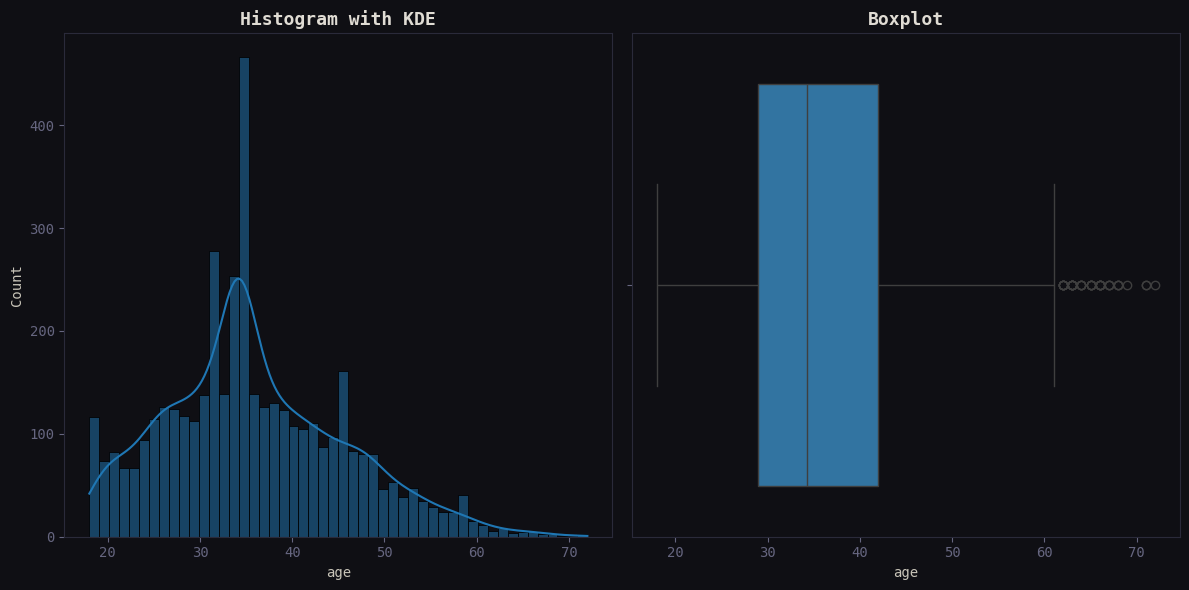

In [16]:
plt.figure(figsize=(12, 6))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True, bins=50)

plt.title('Histogram with KDE')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['age'])
plt.title('Boxplot')

plt.tight_layout()
plt.show()

Age column is not normally distributed with max customers with the age around the age 35 and by looking at the boxplot there seems to be presence of outliers but in real life scenario these values are absolutely possible.

Col = quantity

step 1: Since this column has been cleaned, need to check for outliers

In [17]:
res = detect_outliers(df, 'quantity')
display(res['quantity'])

,quantity
240,999
997,999
1095,999
1120,999
1674,999
2140,999
2536,999
3784,999


Step 2: need to check for the percentage of these outlier values, if tge percenatge < 1% we can drop those rows

In [18]:
num_outliers = len(detect_outliers(df, 'quantity'))
percentage_outliers = (num_outliers / len(df)) * 100
print(f"Percentage of outliers in 'quantity': {percentage_outliers:.2f}%")

Percentage of outliers in 'quantity': 0.19%


Step 3: Dropping these rows

In [19]:
# Drop the outlier rows from the main DataFrame
df.drop(res.index, inplace=True)

# Display the new shape of the DataFrame to confirm the rows have been dropped
print(f"New shape of the DataFrame after dropping outliers: {df.shape}")

New shape of the DataFrame after dropping outliers: (4192, 21)


Step 4: plot histogram with kde and boxplots

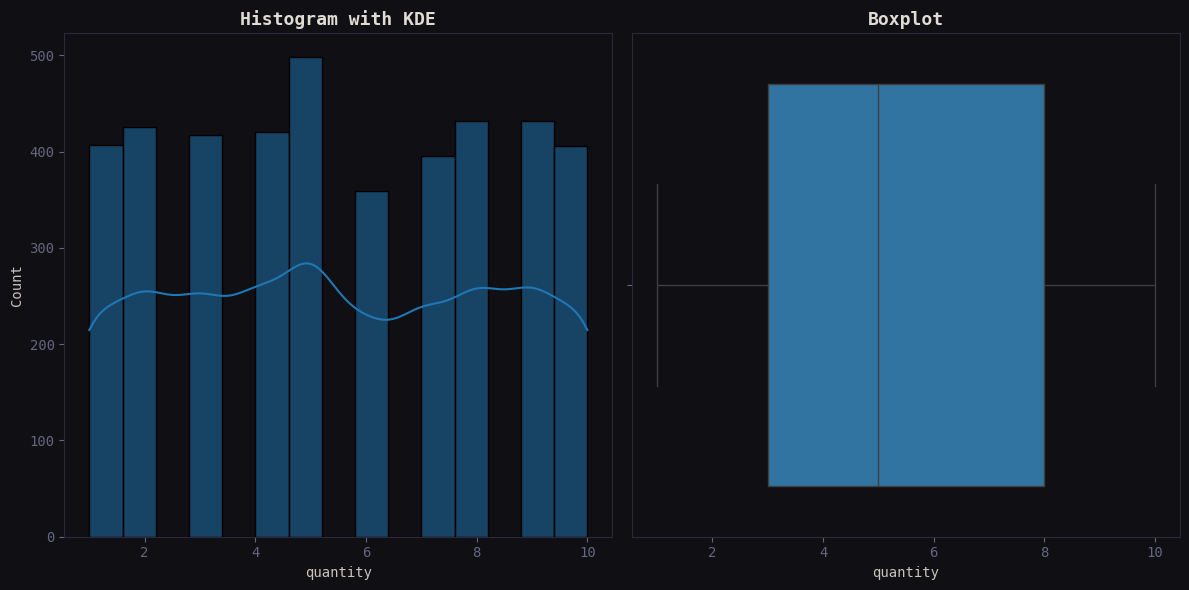

In [20]:
plt.figure(figsize=(12, 6))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['quantity'], kde=True)

plt.title('Histogram with KDE')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['quantity'])
plt.title('Boxplot')

plt.tight_layout()
plt.show()

Quantity values ranges from 1 to 10, with no outliers present

Col = unit_price

Step 1: Checking for outliers

In [21]:
res = detect_outliers(df, 'unit_price')
display(res['unit_price'])

,unit_price
17,73558.44
19,34890.63
20,48577.53
28,63147.82
32,33537.06
...,...
4087,56628.56
4115,34040.99
4118,76773.58
4148,44361.97


While these may be outliers statistically but in real world scenario these prices are possible.

Step 2: plot histogram with kde and boxplot

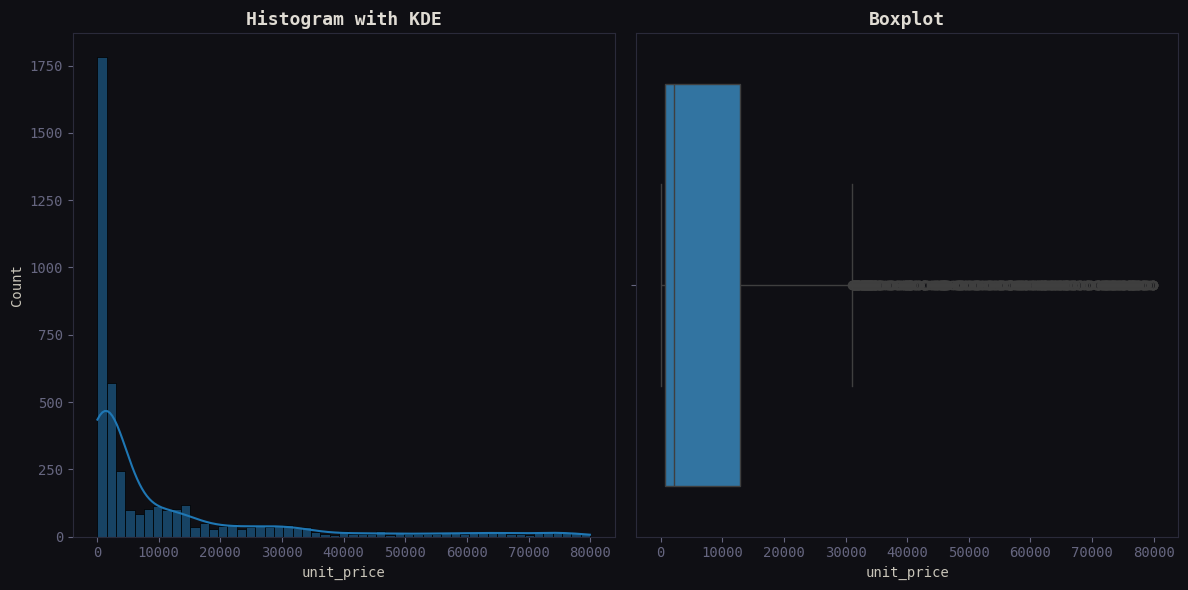

In [22]:
plt.figure(figsize=(12,6))

plt.subplot(1, 2, 1)
sns.histplot(df['unit_price'], kde=True)
plt.title('Histogram with KDE')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['unit_price'])
plt.title('Boxplot')

plt.tight_layout()
plt.show()

The distribution is right skewes with maximum values present in the lower side.

Col = discount_pct

Step 1: Checking for outliers

In [23]:
res = detect_outliers(df, 'discount_pct')
display(res['discount_pct'])

,discount_pct


Step 2: plot histogram and boxplots

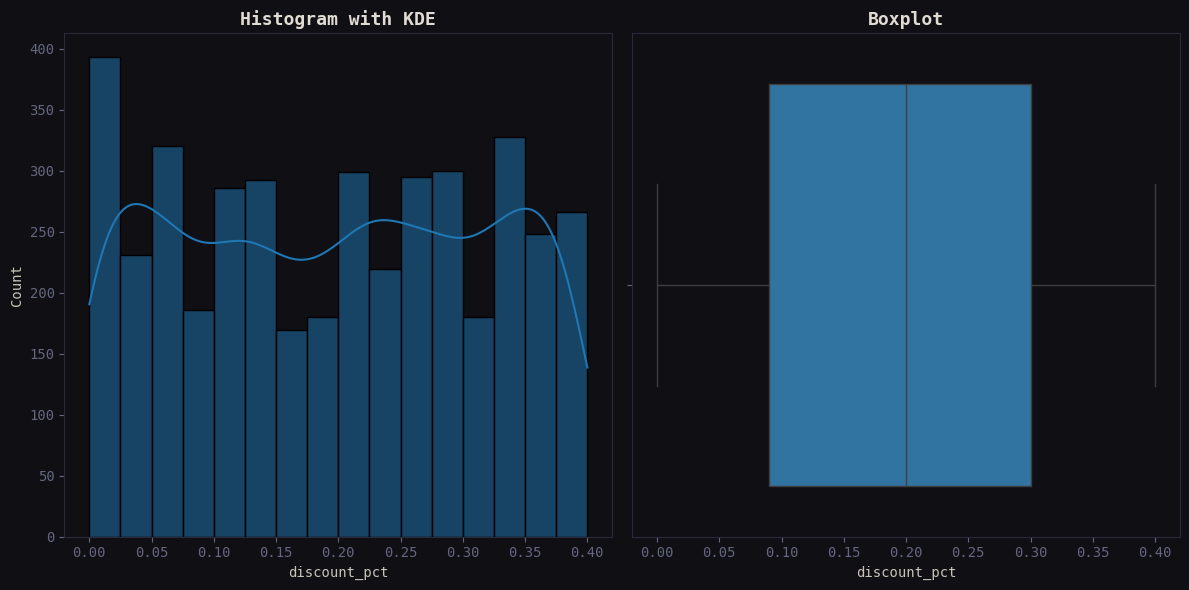

In [24]:
plt.figure(figsize=(12, 6))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['discount_pct'], kde=True)

plt.title('Histogram with KDE')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['discount_pct'])
plt.title('Boxplot')

plt.tight_layout()
plt.show()

The distribution seems fairly normal

col = sales_amount

Step 1: Checking for outliers

In [25]:
res = detect_outliers(df, 'sales_amount')
display(res['sales_amount'])

,sales_amount
3,262066.11
15,144295.18
17,315130.44
20,483408.08
28,671607.78
...,...
4159,931056.13
4167,142656.40
4176,123725.25
4183,212852.52


Step 2: Checking the percentages of these outliers

In [26]:
num_outliers_sales = len(res)
percentage_outliers_sales = (num_outliers_sales / len(df)) * 100
print(f"Percentage of outliers in 'sales_amount': {percentage_outliers_sales:.2f}%")

Percentage of outliers in 'sales_amount': 13.88%


Step 3: Given that the percentage of outliers in `sales_amount` is 13.88%, simply dropping these rows might lead to a significant loss of data. Instead, we can cap the outlier values to a reasonable threshold, often using the upper bound from the IQR method.


In [27]:
# Recalculate IQR bounds for 'sales_amount' for capping
q1_sales = df['sales_amount'].quantile(0.25)
q3_sales = df['sales_amount'].quantile(0.75)
IQR_sales = q3_sales - q1_sales
upper_bound_sales = q3_sales + 1.5 * IQR_sales

# Cap the outliers in 'sales_amount' to the upper bound
df['sales_amount'] = np.where(df['sales_amount'] > upper_bound_sales, upper_bound_sales, df['sales_amount'])

print(f"Upper bound used for capping sales_amount: {upper_bound_sales:.2f}")

# Verify that there are no more values above the new upper bound
print(f"Number of sales_amount values still above the original upper bound after capping: {len(df[df['sales_amount'] > upper_bound_sales])}")

Upper bound used for capping sales_amount: 121504.81
Number of sales_amount values still above the original upper bound after capping: 0


In [82]:
# again checking for outliers
res = detect_outliers(df, 'sales_amount')
display(res['sales_amount'])

,sales_amount
3,121504.8125
15,121504.8125
17,121504.8125
20,121504.8125
28,121504.8125
...,...
4159,121504.8125
4167,121504.8125
4176,121504.8125
4183,121504.8125


In [83]:
# need to again cap these  outliers to upper bound
df['sales_amount'] = np.where(df['sales_amount'] > upper_bound_sales, upper_bound_sales, df['sales_amount'])

print(f"Upper bound used for capping sales_amount: {upper_bound_sales:.2f}")

Upper bound used for capping sales_amount: 121504.81


Step 4: Plot using histogram and boxplot

In [85]:
def iterative_cap_outliers(df, col, detect_outliers_func, max_iterations=100):
    '''
    Iteratively caps outliers in a specified column until no more outliers are detected
    by the provided detect_outliers_func.
    '''
    current_df = df.copy()
    iteration = 0
    while True and iteration < max_iterations:
        outliers = detect_outliers_func(current_df, col)
        if outliers.empty:
            break

        q1 = current_df[col].quantile(0.25)
        q3 = current_df[col].quantile(0.75)
        IQR = q3 - q1
        lower_bound = q1 - 1.5 * IQR
        upper_bound = q3 + 1.5 * IQR

        # Cap values only if they are above the upper bound (or below lower for negative)
        current_df[col] = np.where(current_df[col] > upper_bound, upper_bound, current_df[col])
        current_df[col] = np.where(current_df[col] < lower_bound, lower_bound, current_df[col])

        iteration += 1
        if iteration == max_iterations:
            print(f"Warning: Max iterations reached ({max_iterations}). Outliers might still exist.")

    print(f"Iterative capping completed for '{col}' in {iteration} iterations.")
    return current_df

Let's apply this iterative capping function to `sales_amount` to ensure no more outliers are detected by our `detect_outliers` function.

In [86]:
# Apply iterative capping to 'sales_amount'
df = iterative_cap_outliers(df, 'sales_amount', detect_outliers)

# Re-check for outliers in 'sales_amount' after iterative capping
res_sales_iterative = detect_outliers(df, 'sales_amount')
print("Outliers in 'sales_amount' after iterative capping:")
display(res_sales_iterative['sales_amount'])

# Verify that there are no more values above the newly calculated upper bound
# (The upper_bound will shift with each iteration, so we re-calculate it for final check)
q1_final = df['sales_amount'].quantile(0.25)
q3_final = df['sales_amount'].quantile(0.75)
IQR_final = q3_final - q1_final
upper_bound_final = q3_final + 1.5 * IQR_final

print(f"\nNumber of sales_amount values still above the *final* upper bound after iterative capping: {len(df[df['sales_amount'] > upper_bound_final])}")

Iterative capping completed for 'sales_amount' in 1 iterations.
Outliers in 'sales_amount' after iterative capping:


,sales_amount



Number of sales_amount values still above the *final* upper bound after iterative capping: 0


### Step 4: Plot using histogram and boxplot after iterative capping

Now, let's visualize the `sales_amount` distribution again to see the effect of iterative capping. You should observe a much 'cleaner' boxplot with fewer, if any, visible statistical outliers.

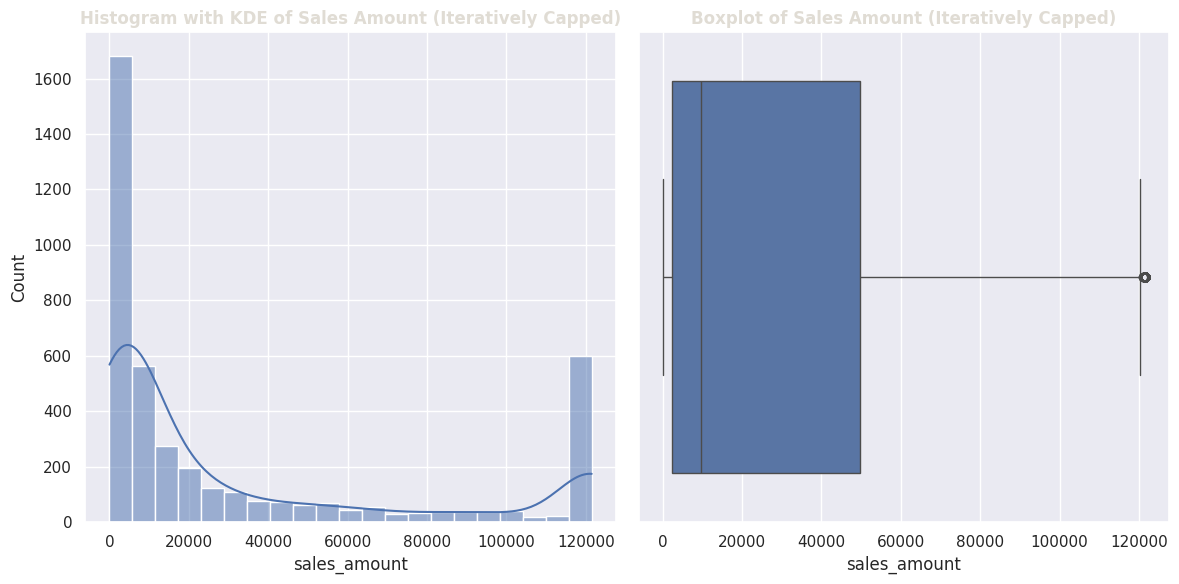

In [84]:
plt.figure(figsize=(12, 6))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['sales_amount'], kde=True)
plt.title('Histogram with KDE of Sales Amount (Iteratively Capped)')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['sales_amount'])
plt.title('Boxplot of Sales Amount (Iteratively Capped)')

plt.tight_layout()
plt.show()

As we can see, by iteratively capping the outliers, we have adjusted the distribution such that our `detect_outliers` function (using the 1.5 IQR rule) no longer flags any values as outliers. This approach effectively 'forces' the data into a distribution where no values fall outside the recalculated IQR bounds.

**Important Consideration:** While this method eliminates statistical outliers by the defined rule, it also compresses extreme values, which might lead to a loss of information or distort the true nature of your data if those extreme values were meaningful. Always consider the business context and the implications of such aggressive data manipulation.

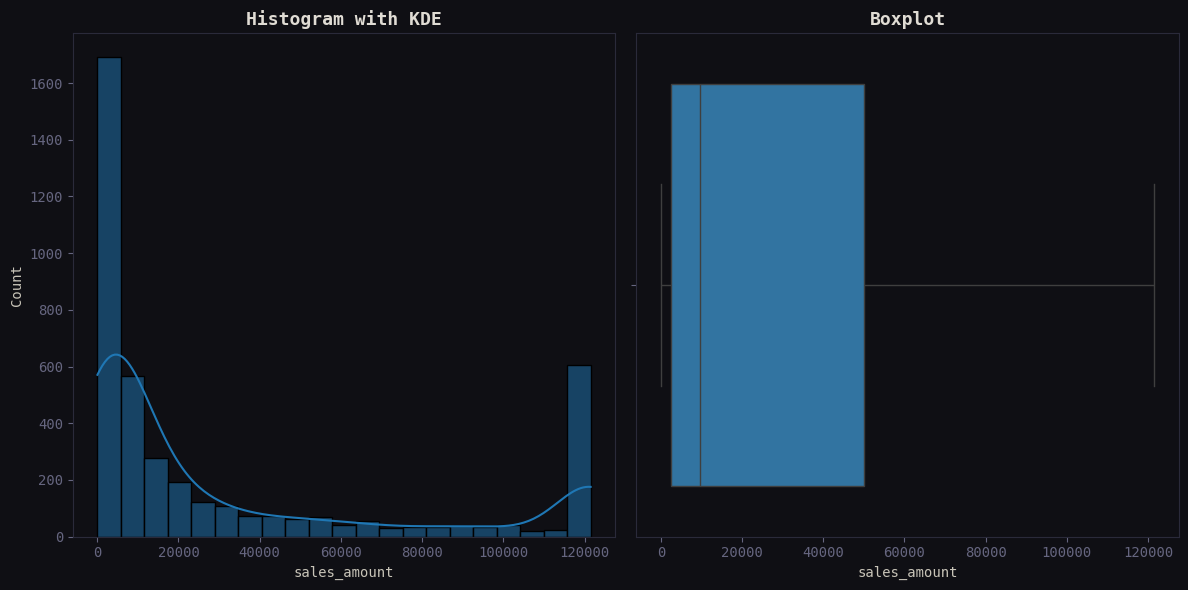

In [28]:
plt.figure(figsize=(12, 6))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['sales_amount'], kde=True)

plt.title('Histogram with KDE')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['sales_amount'])
plt.title('Boxplot')

plt.tight_layout()
plt.show()

The data is fairly right skewed with no outliers present

Col = profit

Step 1: Checking for outliers

In [29]:
res = detect_outliers(df, 'profit')
display(res['profit'])

,profit
2,36956.51
3,66644.99
15,50995.28
17,53808.65
20,36816.91
...,...
4167,33781.29
4176,32970.37
4183,53977.66
4193,30233.13


### Step 2: Checking the percentages of these outliers

In [30]:
num_outliers_profit = len(res)
percentage_outliers_profit = (num_outliers_profit / len(df)) * 100
print(f"Percentage of outliers in 'profit': {percentage_outliers_profit:.2f}%")

Percentage of outliers in 'profit': 12.95%


### Step 3: Cap the outliers in 'profit'
Given the significant percentage of outliers, dropping them would lead to substantial data loss. Capping them at the upper IQR bound is a better approach.

In [31]:
q1_profit = df['profit'].quantile(0.25)
q3_profit = df['profit'].quantile(0.75)
IQR_profit = q3_profit - q1_profit
upper_bound_profit = q3_profit + 1.5 * IQR_profit

# Cap the outliers in 'profit' to the upper bound
df['profit'] = np.where(df['profit'] > upper_bound_profit, upper_bound_profit, df['profit'])

print(f"Upper bound used for capping profit: {upper_bound_profit:.2f}")

# Verify that there are no more values above the new upper bound
print(f"Number of profit values still above the original upper bound after capping: {len(df[df['profit'] > upper_bound_profit])}")

Upper bound used for capping profit: 25025.26
Number of profit values still above the original upper bound after capping: 0


### Step 4: Plot histogram with KDE and boxplot after capping

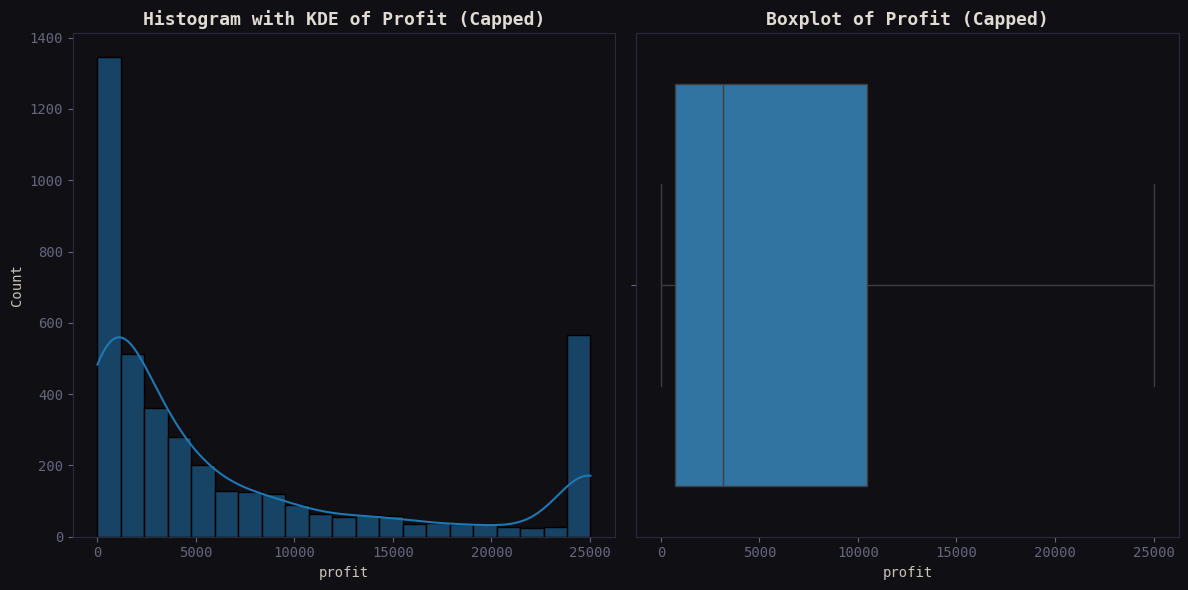

In [32]:
plt.figure(figsize=(12, 6))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['profit'], kde=True)
plt.title('Histogram with KDE of Profit (Capped)')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['profit'])
plt.title('Boxplot of Profit (Capped)')

plt.tight_layout()
plt.show()

Distrobution is right skewed with no outliers

Col = shipping_cost

Step 1: Checking for outliers

In [33]:
res = detect_outliers(df, 'shipping_cost')
display(res['shipping_cost'])

,shipping_cost
228,115.73
752,8.31
864,10.03
946,117.75
1048,114.04
1143,0.51
1312,112.99
2382,119.62
2772,1.60
2909,133.35


### Step 2: Checking the percentages of these outliers

In [34]:
num_outliers_shipping_cost = len(res)
percentage_outliers_shipping_cost = (num_outliers_shipping_cost / len(df)) * 100
print(f"Percentage of outliers in 'shipping_cost': {percentage_outliers_shipping_cost:.2f}%")

Percentage of outliers in 'shipping_cost': 0.41%


### Step 3: Dropping these rows
Given that the percentage of outliers in `shipping_cost` is less than 1%, we can drop these rows without significant data loss.

In [35]:
# Drop the outlier rows from the main DataFrame
df.drop(res.index, inplace=True)

# Display the new shape of the DataFrame to confirm the rows have been dropped
print(f"New shape of the DataFrame after dropping shipping_cost outliers: {df.shape}")

New shape of the DataFrame after dropping shipping_cost outliers: (4175, 21)


### Step 4: Plot histogram with KDE and boxplot after dropping outliers

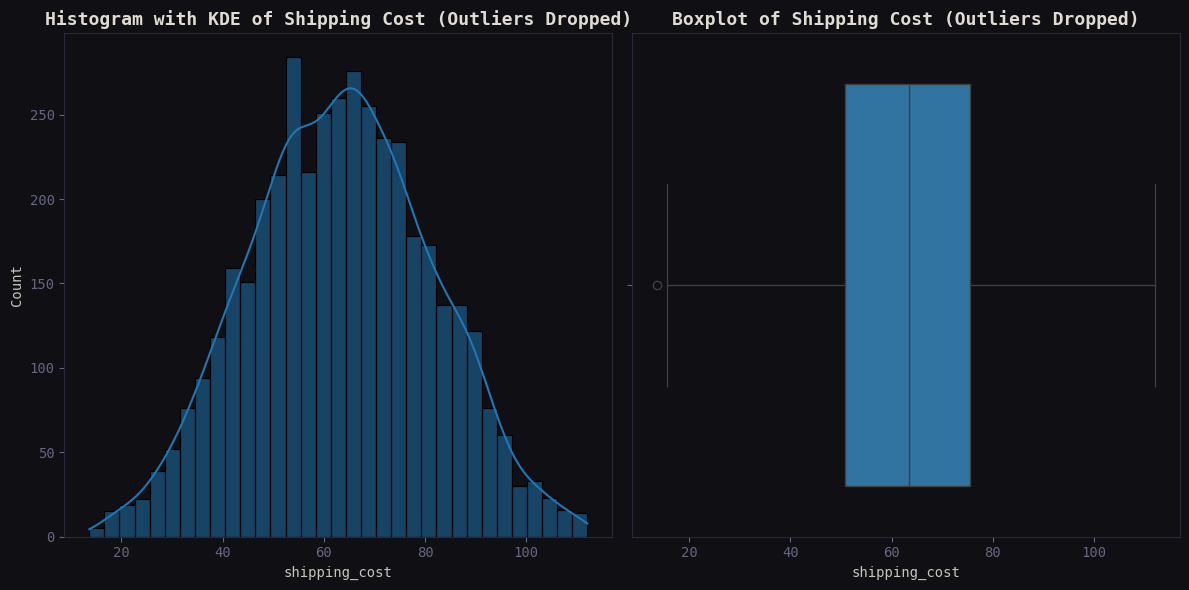

In [36]:
plt.figure(figsize=(12, 6))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['shipping_cost'], kde=True)
plt.title('Histogram with KDE of Shipping Cost (Outliers Dropped)')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['shipping_cost'])
plt.title('Boxplot of Shipping Cost (Outliers Dropped)')

plt.tight_layout()
plt.show()

Distribution is fairly normal with no outliers

Col = days_to_ship

Step 1: Checking for outliers

In [37]:
res = detect_outliers(df, 'days_to_ship')
display(res['days_to_ship'])

,days_to_ship
57,45
916,100
2186,100
2753,100
2812,45
3432,100


Step 2: checking for percentages of these outliers

In [38]:
num_outliers_days_to_ship = len(detect_outliers(df, 'days_to_ship'))
percentage_outliers_days_to_ship = (num_outliers_days_to_ship / len(df)) * 100
print(f"Percentage of outliers in 'days_to_ship': {percentage_outliers_days_to_ship:.2f}%")

Percentage of outliers in 'days_to_ship': 0.14%


Step 3: Since the percentage < 1%, we can drop these rows

In [39]:
# Drop the outlier rows from the main DataFrame
df.drop(res.index, inplace=True)

# Display the new shape of the DataFrame to confirm the rows have been dropped
print(f"New shape of the DataFrame after dropping days_to_ship outliers: {df.shape}")

New shape of the DataFrame after dropping days_to_ship outliers: (4169, 21)


Step 4: PLot histogram with KDE and boxplot

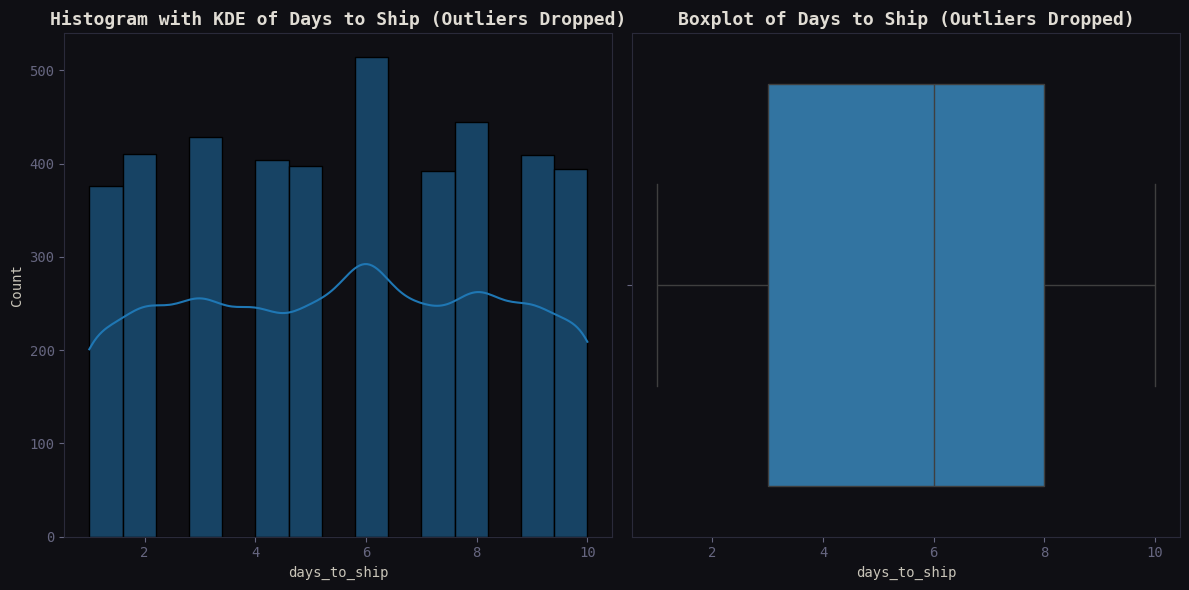

In [40]:
plt.figure(figsize=(12, 6))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['days_to_ship'], kde=True)
plt.title('Histogram with KDE of Days to Ship (Outliers Dropped)')

# boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['days_to_ship'])
plt.title('Boxplot of Days to Ship (Outliers Dropped)')

plt.tight_layout()
plt.show()

Failry normal distribution

# Univariate analysis on categorical columns

Categorical Columns = {gender, region, city, product_category, product_name, payment_method, customer_satisfaction, return_flag, order_status}

Col = gender, 1: Male, 2: Female, 3: other

Step 1: Checking the value counts

In [41]:
df['gender'].value_counts(dropna = False)

,count
gender,
3,1412
1,1398
2,1359


Step 2: Plot countplots to see distribution

/tmp/ipykernel_1797/614804314.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['gender'], palette=ACCENT) # Use the global ACCENT palette
/tmp/ipykernel_1797/614804314.py:2: UserWarning: The palette list has more values (7) than needed (3), which may not be intended.
  sns.countplot(x=df['gender'], palette=ACCENT) # Use the global ACCENT palette


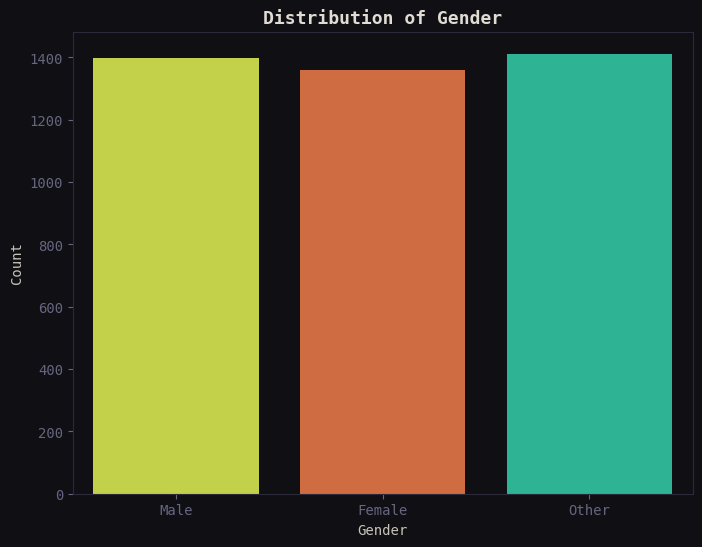

In [42]:
plt.figure(figsize=(8, 6))
sns.countplot(x=df['gender'], palette=ACCENT) # Use the global ACCENT palette
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks([0, 1, 2], ['Male', 'Female', 'Other']) # Map numerical labels to descriptive names
plt.show()

Customers wise Other buyers are the most followed by Male and then followed by Female

Col = region

Step 1: Value counts of region

In [43]:
df['region'].value_counts(dropna = False)

,count
region,
W,869
S,860
N,840
E,821
C,779


Step 2: plot countplots

/tmp/ipykernel_1797/3663180194.py:3: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.countplot(x=df['region'], hue=df['region'], palette=ACCENT, legend=False)


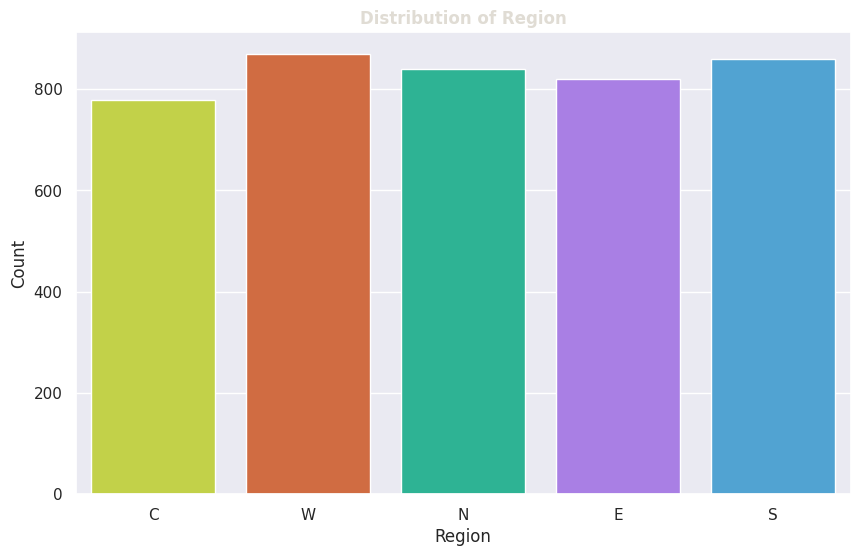

In [44]:
sns.set_theme(style="darkgrid") # Ensure dark theme is applied for seaborn plots
plt.figure(figsize=(10, 6))
sns.countplot(x=df['region'], hue=df['region'], palette=ACCENT, legend=False)
plt.title('Distribution of Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

We can see that West and South region has the most number of orders

Col = city

Step 1: Checking value counts

In [45]:
df['city'].value_counts(dropna = False)

,count
city,
Surat,232
Amritsar,231
Guwahati,228
Chennai,228
Mumbai,226
Hyderabad,220
Raipur,219
Chandigarh,213
Ahmedabad,211


Step 2: plot count plots

/tmp/ipykernel_1797/507472376.py:3: UserWarning: 
The palette list has fewer values (7) than needed (20) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x=df['city'], hue=df['city'], palette=ACCENT, legend=False)


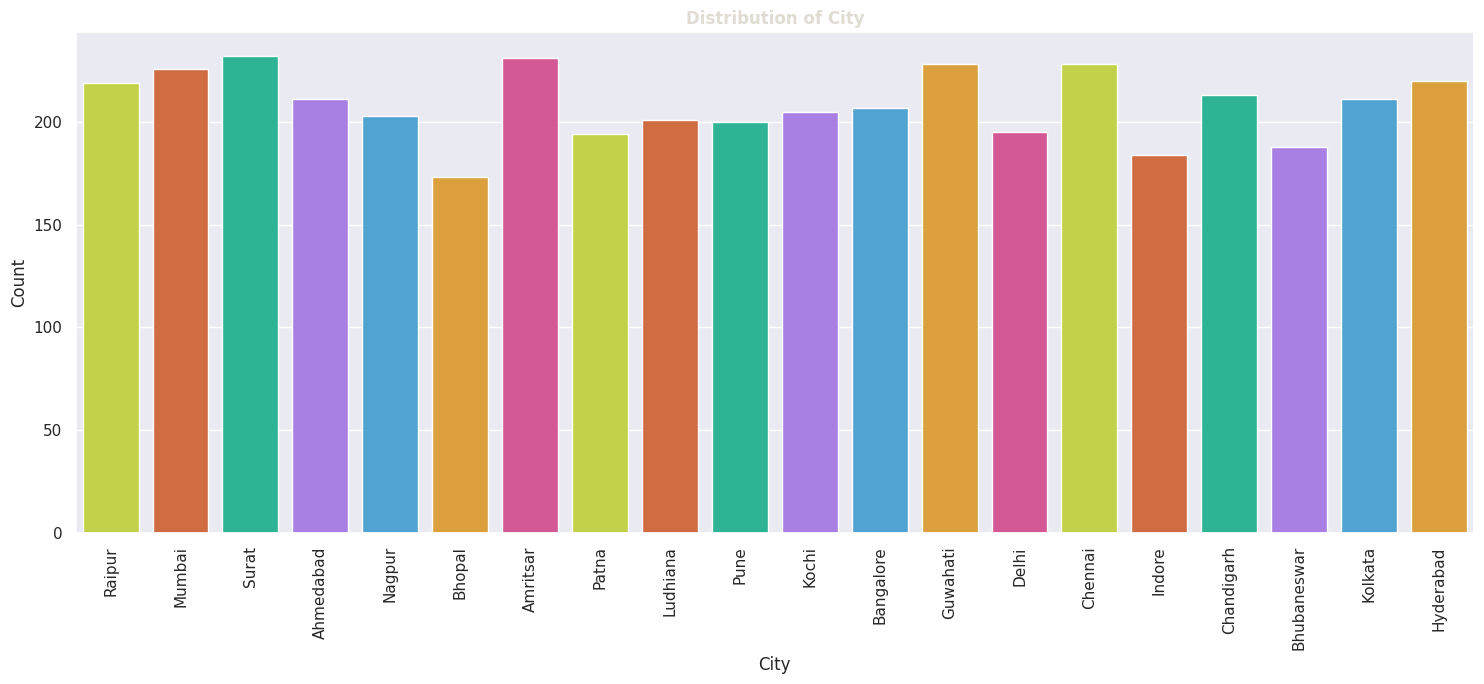

In [46]:
sns.set_theme(style="darkgrid") # Ensure dark theme is applied for seaborn plots
plt.figure(figsize=(15, 7)) # Increased figure size for better readability of many cities
sns.countplot(x=df['city'], hue=df['city'], palette=ACCENT, legend=False)
plt.title('Distribution of City')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Most of the customers are from Amritsar, Surat, Guwahati, Chennai

Col = product_category

Step 1: checking value_counts

In [47]:
df['product_category'].value_counts(dropna = False)

,count
product_category,
Clothing,626
Sports,612
Groceries,604
Electronics,602
Beauty,598
Furniture,570
Books,557


Step 2: plotting count plots

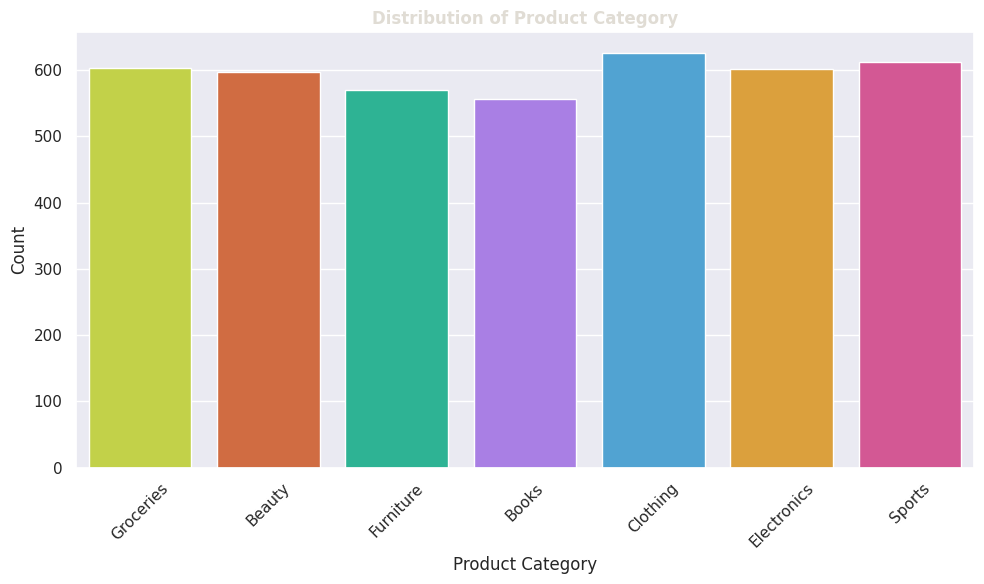

In [48]:
sns.set_theme(style="darkgrid") # Ensure dark theme is applied for seaborn plots
plt.figure(figsize=(10, 6))
sns.countplot(x=df['product_category'], hue=df['product_category'], palette=ACCENT, legend=False)
plt.title('Distribution of Product Category')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.xticks(rotation=45) # Rotate x-axis labels for better readability if categories are long
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Clothing and sports are the most selling product_category

Col = product_name

Step 1: checking number of products

In [49]:
df['product_name'].unique()

array(['Sugar', 'Sunscreen', 'Sofa', 'Bed Frame', 'Cooking Oil',
       'Self-Help Book', 'Saree', 'Kurta', 'Wardrobe', 'Dal (1Kg)',
       'Lipstick', 'Cook Book', 'T-Shirt', 'Chair', 'Dress', 'Tablet',
       'Jacket', 'Headphones', 'Dumbbells', 'Comic Book', 'Football',
       'Laptop', 'Cricket Bat', 'Hair Oil', 'Bookshelf', 'Camera',
       'Jeans', 'Tennis Racket', 'Desk', 'Face Cream', 'Fiction Novel',
       'Cycle', 'Textbook', 'Smartwatch', 'Rice (5Kg)', 'Tea', 'Flour',
       'Perfume', 'Yoga Mat', 'Smartphone', 'Biography', 'Shampoo'],
      dtype=object)

Step 2: Checking for top 10 most ordered products

/tmp/ipykernel_1797/1855371230.py:12: UserWarning: 
The palette list has fewer values (7) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x=df_top_10['product_name'], order=top_10_products, hue=df_top_10['product_name'], palette=ACCENT, legend=False)


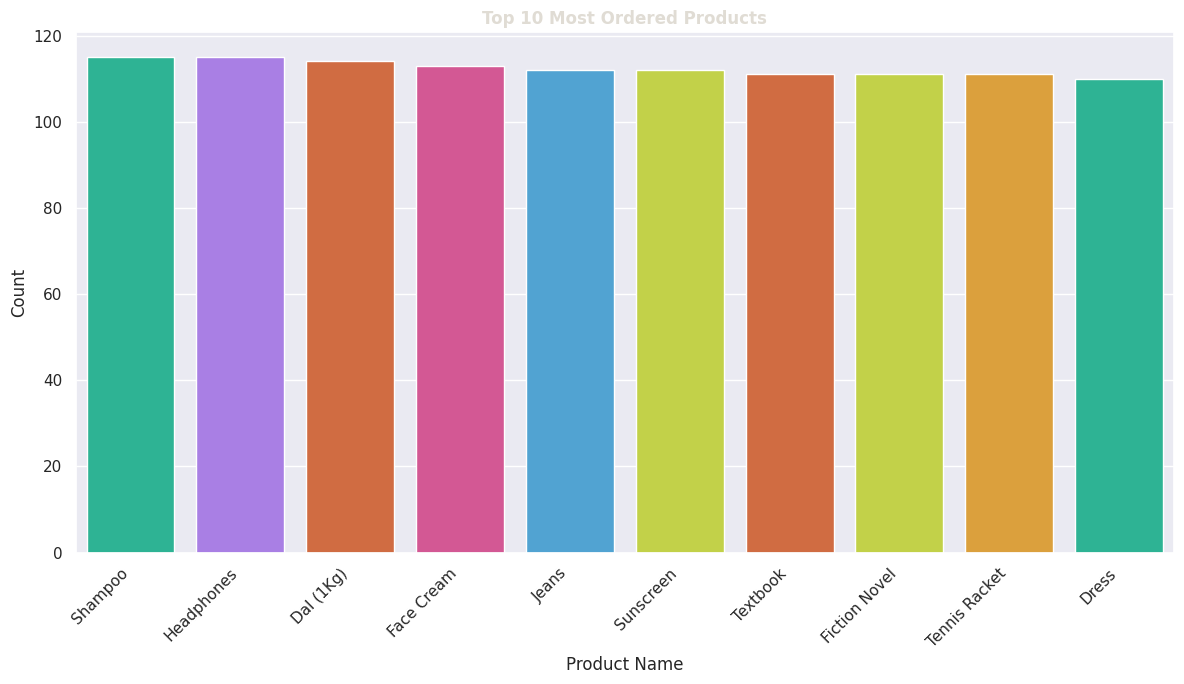

In [50]:
# Get the top 10 most ordered products
top_10_products = df['product_name'].value_counts().head(10).index

# Filter the DataFrame to include only these top 10 products for plotting
df_top_10 = df[df['product_name'].isin(top_10_products)]

sns.set_theme(style="darkgrid") # Ensure dark theme is applied for seaborn plots
plt.figure(figsize=(12, 7))

# Create the countplot for the top 10 products
# Use hue for consistent coloring with ACCENT palette, disable legend as it's redundant
sns.countplot(x=df_top_10['product_name'], order=top_10_products, hue=df_top_10['product_name'], palette=ACCENT, legend=False)

plt.title('Top 10 Most Ordered Products')
plt.xlabel('Product Name')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

The order frequency of all of these top 10 products are almost similar

Col = payment_method

Step 1: checking types of payment_method

In [51]:
df['payment_method'].unique()

array(['Debit Card', 'Emi', 'Net Banking', 'Cash On Delivery',
       'Credit Card', 'Upi'], dtype=object)

Step 2: Plotting countplots

/tmp/ipykernel_1797/2592474926.py:3: UserWarning: The palette list has more values (7) than needed (6), which may not be intended.
  sns.countplot(x=df['payment_method'], hue=df['payment_method'], palette=ACCENT, legend=False)


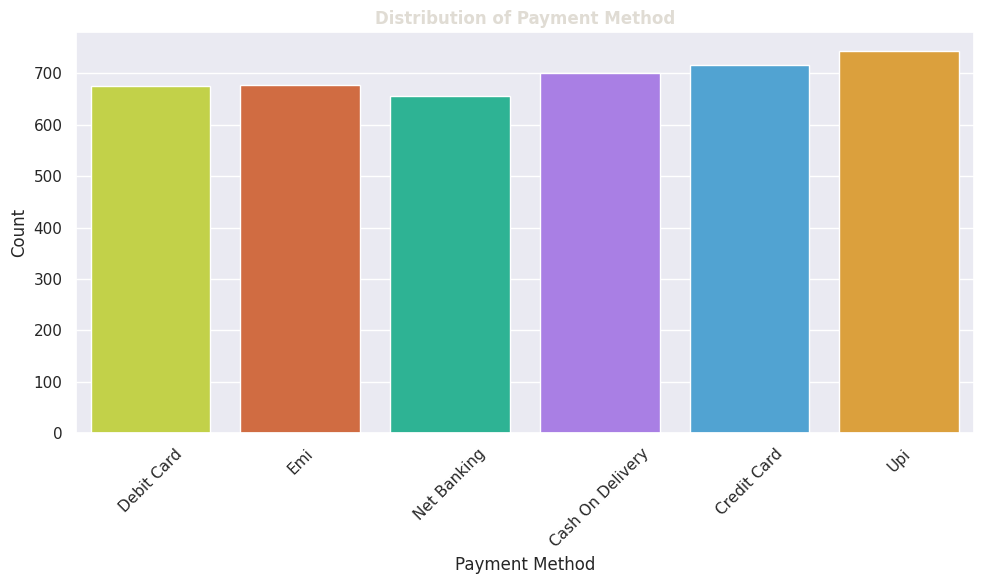

In [52]:
sns.set_theme(style="darkgrid") # Ensure dark theme is applied for seaborn plots
plt.figure(figsize=(10, 6))
sns.countplot(x=df['payment_method'], hue=df['payment_method'], palette=ACCENT, legend=False)
plt.title('Distribution of Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

The most used payment method is UPI

Col = customer_satisfaction

Step 1: Checking the value counts

In [53]:
df['customer_satisfaction'].value_counts(dropna = False)

,count
customer_satisfaction,
3,1085
4,806
5,766
2,758
1,754


Step 2: PLot count plot

/tmp/ipykernel_1797/28350183.py:3: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.countplot(x=df['customer_satisfaction'], hue=df['customer_satisfaction'], palette=ACCENT, legend=False)


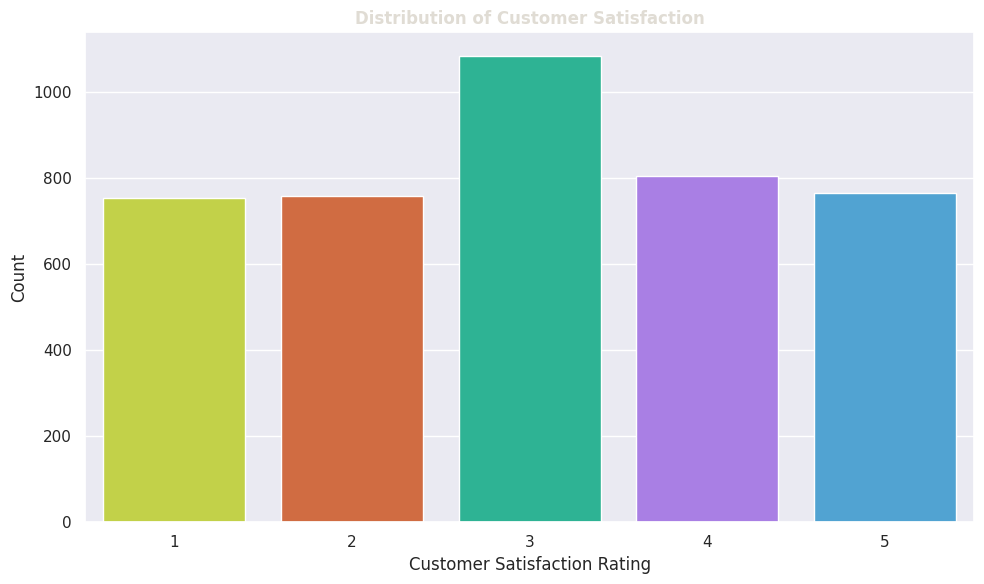

In [54]:
sns.set_theme(style="darkgrid") # Ensure dark theme is applied for seaborn plots
plt.figure(figsize=(10, 6))
sns.countplot(x=df['customer_satisfaction'], hue=df['customer_satisfaction'], palette=ACCENT, legend=False)
plt.title('Distribution of Customer Satisfaction')
plt.xlabel('Customer Satisfaction Rating')
plt.ylabel('Count')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Step 3: We can also check for avg ratings given and plot it using count plot

Average customer satisfaction by product category:


,customer_satisfaction
product_category,
Books,3.096948
Clothing,3.067093
Beauty,3.035117
Furniture,3.029825
Electronics,3.000000
Groceries,2.985099
Sports,2.913399


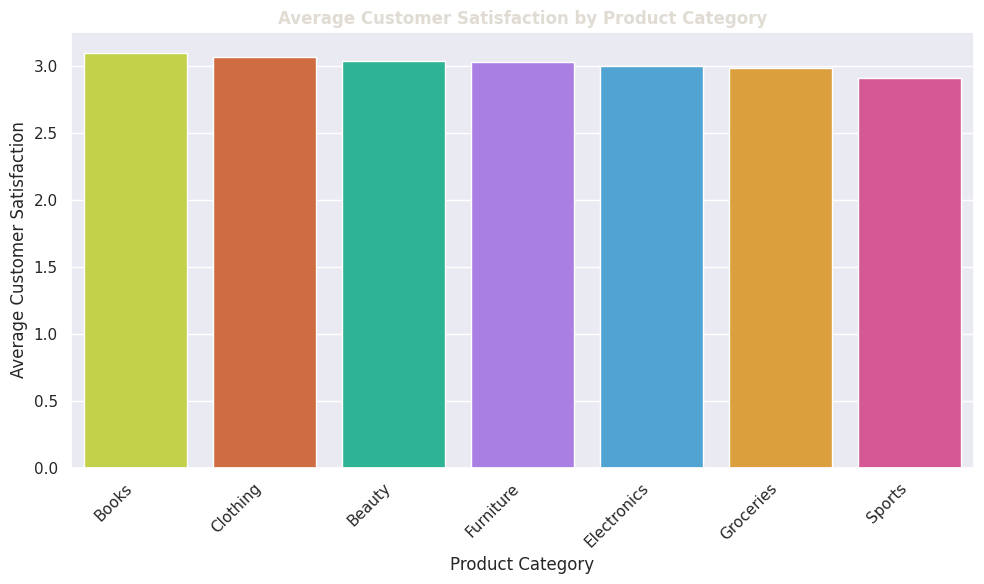

In [55]:
avg_satisfaction_by_category = df.groupby('product_category')['customer_satisfaction'].mean().sort_values(ascending=False)

print("Average customer satisfaction by product category:")
display(avg_satisfaction_by_category)

sns.set_theme(style="darkgrid") # Ensure dark theme is applied for seaborn plots
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_satisfaction_by_category.index, y=avg_satisfaction_by_category.values, palette=ACCENT, hue=avg_satisfaction_by_category.index, legend=False)
plt.title('Average Customer Satisfaction by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Customer Satisfaction')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Col = return_flag

Step 1: Value counts and plot it using count plot

Value counts for 'return_flag':


,count
return_flag,
0,3560
1,609


/tmp/ipykernel_1797/2576615925.py:6: UserWarning: The palette list has more values (7) than needed (2), which may not be intended.
  sns.countplot(x=df['return_flag'], hue=df['return_flag'], palette=ACCENT, legend=False)


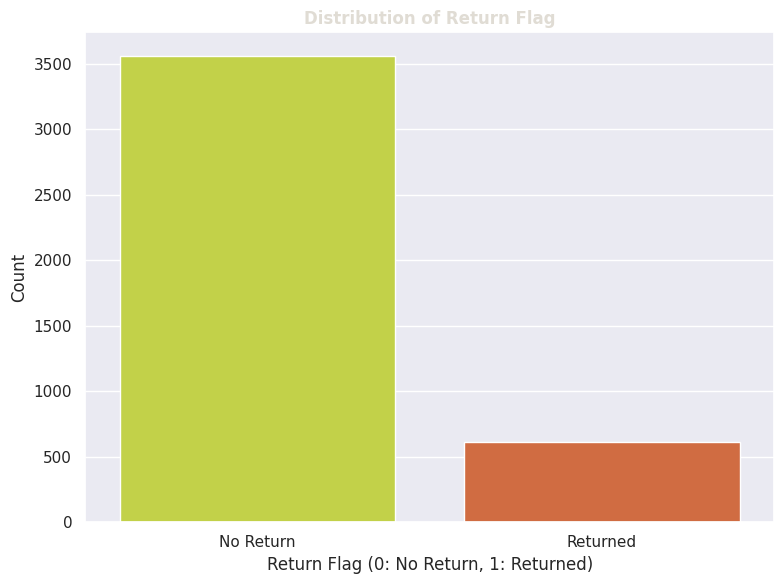

In [56]:
print("Value counts for 'return_flag':")
display(df['return_flag'].value_counts(dropna = False))

sns.set_theme(style="darkgrid") # Ensure dark theme is applied for seaborn plots
plt.figure(figsize=(8, 6))
sns.countplot(x=df['return_flag'], hue=df['return_flag'], palette=ACCENT, legend=False)
plt.title('Distribution of Return Flag')
plt.xlabel('Return Flag (0: No Return, 1: Returned)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Return', 'Returned']) # Label the numerical values with descriptive names
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Majority of the orders have been accepted with few being returned.

Col = order_status

Step 1: checking for value_counts and plot using count plot

Value counts for 'order_status':


,count
order_status,
Delivered,2706
Returned,609
Cancelled,345
Shipped,325
Pending,184


/tmp/ipykernel_1797/1189723091.py:6: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.countplot(x=df['order_status'], hue=df['order_status'], palette=ACCENT, legend=False)


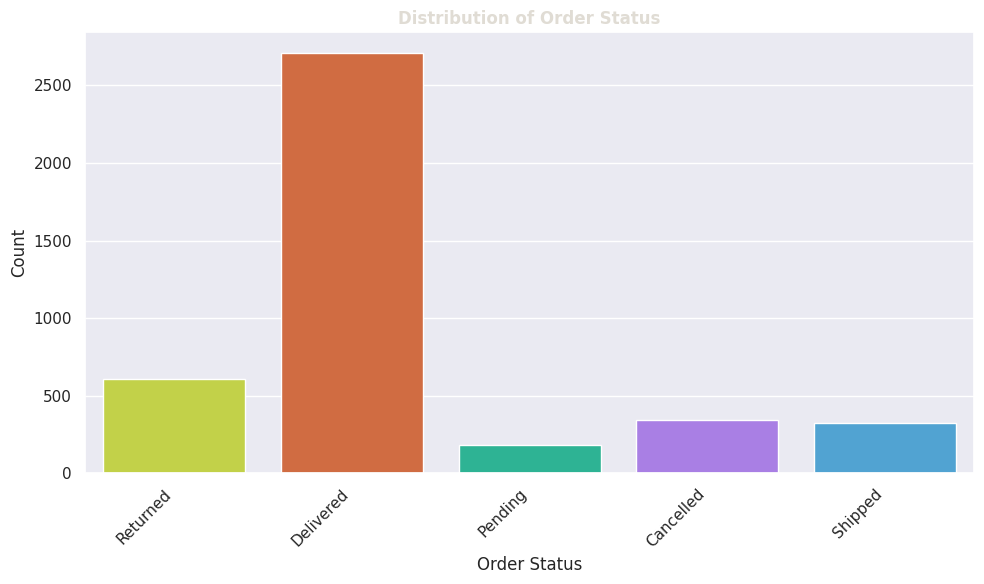

In [57]:
print("Value counts for 'order_status':")
display(df['order_status'].value_counts(dropna = False))

sns.set_theme(style="darkgrid") # Ensure dark theme is applied for seaborn plots
plt.figure(figsize=(10, 6))
sns.countplot(x=df['order_status'], hue=df['order_status'], palette=ACCENT, legend=False)
plt.title('Distribution of Order Status')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Majority of the orders have been delivered successfully

# Bivariate analysis

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4169 entries, 0 to 4199
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               4169 non-null   int64         
 1   order_date             4169 non-null   datetime64[ns]
 2   customer_id            4169 non-null   int64         
 3   customer_name          4169 non-null   object        
 4   age                    4169 non-null   float64       
 5   gender                 4169 non-null   int64         
 6   region                 4169 non-null   object        
 7   city                   4169 non-null   object        
 8   product_category       4169 non-null   object        
 9   product_name           4169 non-null   object        
 10  quantity               4169 non-null   int64         
 11  unit_price             4169 non-null   float64       
 12  discount_pct           4169 non-null   float64       
 13  sales_am

We can check for age group and plot the avg number of orders for that age group

Step 1: We need to define age groups


In [59]:
# Define age bins and labels
age_bins = [0, 25, 55, np.inf]
age_labels = ['Young', 'Adult', 'Senior']

# Create the 'age_group' column
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

print("Value counts for 'age_group':")
display(df['age_group'].value_counts(dropna=False))

Value counts for 'age_group':


,count
age_group,
Adult,3491
Young,495
Senior,183


Step 2: Now using these age groups we need to plot avg number of orders placed

Number of orders by age group:


,count
age_group,
Young,495
Adult,3491
Senior,183


/tmp/ipykernel_1797/4011545291.py:11: UserWarning: The palette list has more values (7) than needed (3), which may not be intended.
  sns.barplot(x=orders_by_age_group.index, y=orders_by_age_group.values, hue=orders_by_age_group.index, palette=ACCENT, legend=False)


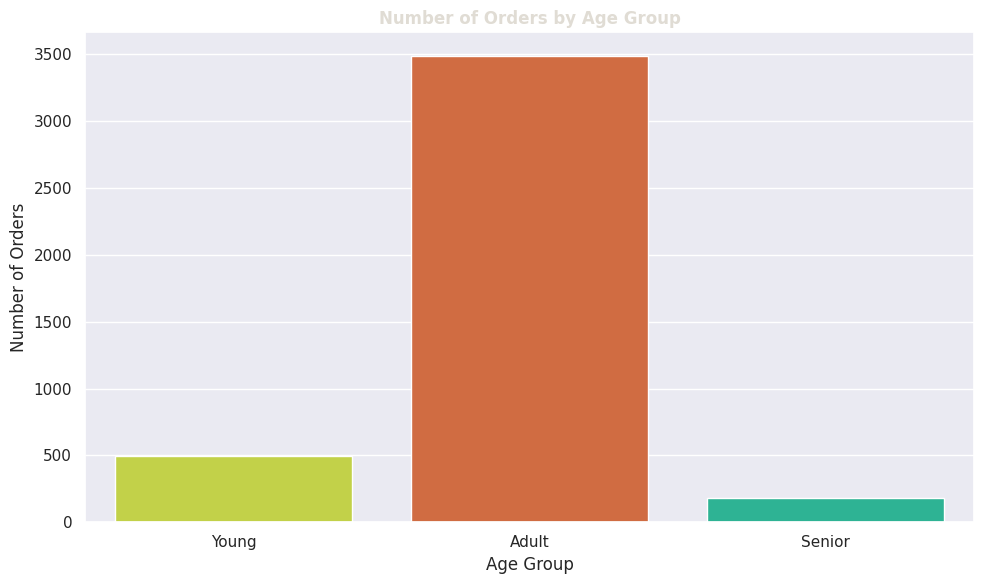

In [60]:
# Calculate the number of orders per age group
orders_by_age_group = df['age_group'].value_counts().sort_index()

print("Number of orders by age group:")
display(orders_by_age_group)

sns.set_theme(style="darkgrid") # Ensure dark theme is applied for seaborn plots
plt.figure(figsize=(10, 6))

# Create the bar plot for orders by age group
sns.barplot(x=orders_by_age_group.index, y=orders_by_age_group.values, hue=orders_by_age_group.index, palette=ACCENT, legend=False)

plt.title('Number of Orders by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Orders')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

We can also plot the age group with the avg amount spent

Step 1: Plot age group vs avg purchase amount

Average sales amount by age group:


/tmp/ipykernel_1797/2465784964.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_sales_by_age_group = df.groupby('age_group')['sales_amount'].mean().sort_values(ascending=False)


,sales_amount
age_group,
Young,35840.331005
Senior,32905.279577
Adult,32491.559645


/tmp/ipykernel_1797/2465784964.py:11: UserWarning: The palette list has more values (7) than needed (3), which may not be intended.
  sns.barplot(x=avg_sales_by_age_group.index, y=avg_sales_by_age_group.values, hue=avg_sales_by_age_group.index, palette=ACCENT, legend=False)


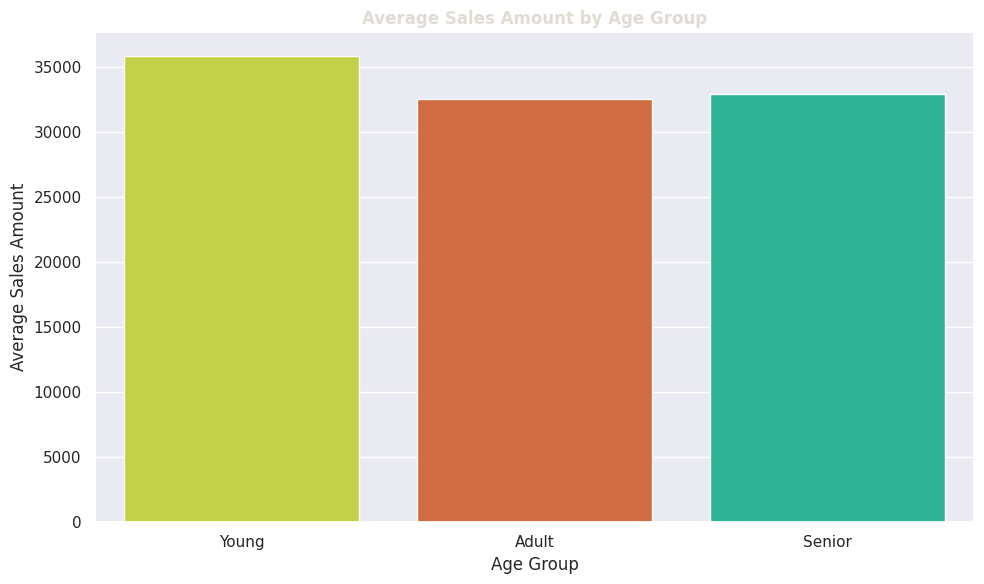

In [61]:
# Calculate the average sales amount per age group
avg_sales_by_age_group = df.groupby('age_group')['sales_amount'].mean().sort_values(ascending=False)

print("Average sales amount by age group:")
display(avg_sales_by_age_group)

sns.set_theme(style="darkgrid") # Ensure dark theme is applied for seaborn plots
plt.figure(figsize=(10, 6))

# Create the bar plot for average sales amount by age group
sns.barplot(x=avg_sales_by_age_group.index, y=avg_sales_by_age_group.values, hue=avg_sales_by_age_group.index, palette=ACCENT, legend=False)

plt.title('Average Sales Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Sales Amount')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Although in the previous graph we saw that adult population has the most number of purchases but this graph shows that young population has the most expenditure with other age groups lagging not much behind

Similarly, we can plot for gender and avg expenditure

Average sales amount by gender:


,sales_amount
gender,
3,34518.771829
1,33382.202698
2,30744.547119


/tmp/ipykernel_1797/2970529424.py:15: UserWarning: The palette list has more values (7) than needed (3), which may not be intended.
  sns.barplot(x=plot_labels, y=avg_sales_by_gender.values, hue=plot_labels, palette=ACCENT, legend=False)


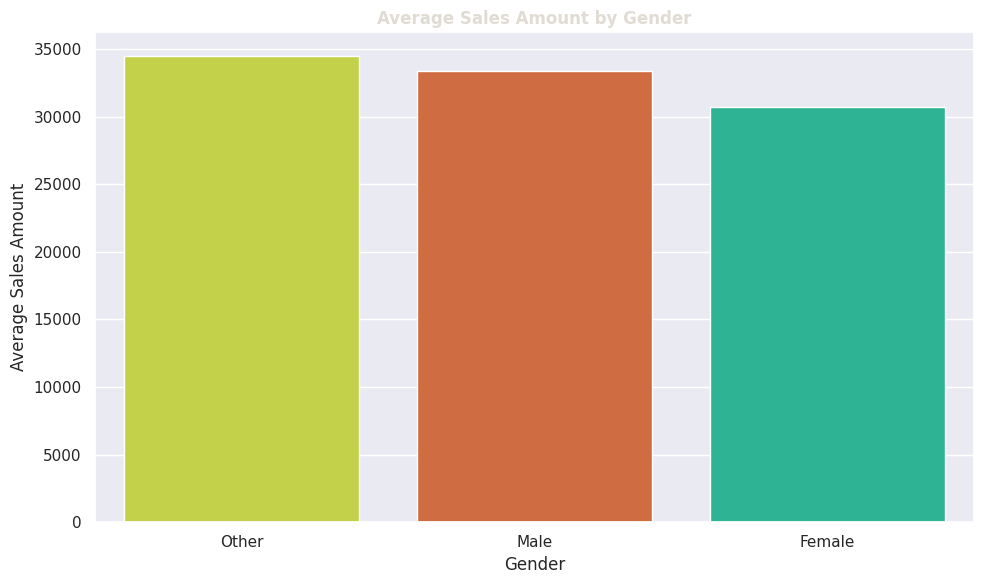

In [62]:
# Calculate the average sales amount per gender
avg_sales_by_gender = df.groupby('gender')['sales_amount'].mean().sort_values(ascending=False)

print("Average sales amount by gender:")
display(avg_sales_by_gender)

sns.set_theme(style="darkgrid") # Ensure dark theme is applied for seaborn plots
plt.figure(figsize=(10, 6))

# Map numerical labels to descriptive names for plotting
gender_labels = {1: 'Male', 2: 'Female', 3: 'Other'}
plot_labels = [gender_labels[g] for g in avg_sales_by_gender.index]

# Create the bar plot for average sales amount by gender
sns.barplot(x=plot_labels, y=avg_sales_by_gender.values, hue=plot_labels, palette=ACCENT, legend=False)

plt.title('Average Sales Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Sales Amount')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

We can also check for each genders' top 5 product category according to number of orders

Top 5 Product Categories by Gender (Number of Orders):


/tmp/ipykernel_1797/1831646337.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_5_products_by_gender = gender_product_counts.groupby('gender', group_keys=False).apply(lambda x: x.nlargest(5, 'count')).reset_index(drop=True)


,gender,product_category,count,gender_label
0,1,Beauty,222,Male
1,1,Clothing,218,Male
2,1,Electronics,211,Male
3,1,Sports,210,Male
4,1,Groceries,197,Male
5,2,Clothing,213,Female
6,2,Books,204,Female
7,2,Groceries,195,Female
8,2,Furniture,194,Female
9,2,Sports,192,Female


/tmp/ipykernel_1797/1831646337.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


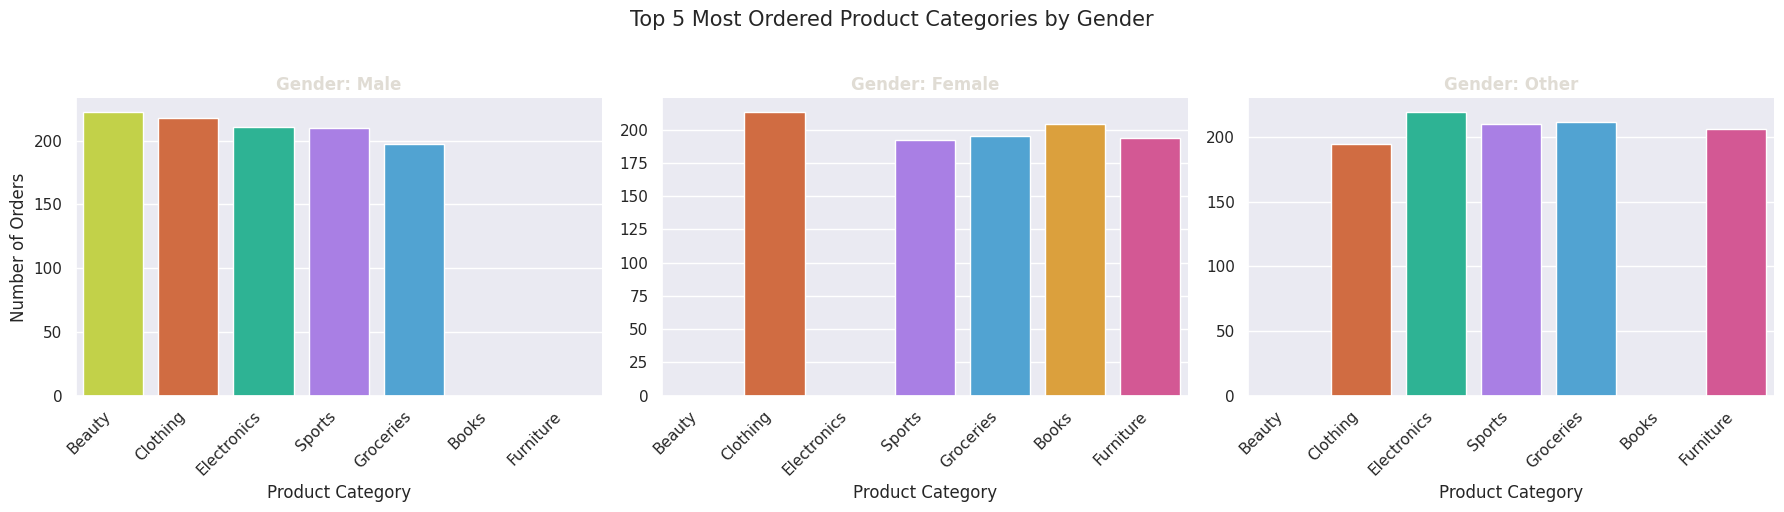

In [63]:
# Calculate the count of each product category for each gender
gender_product_counts = df.groupby(['gender', 'product_category']).size().reset_index(name='count')

# Get the top 5 product categories for each gender
top_5_products_by_gender = gender_product_counts.groupby('gender', group_keys=False).apply(lambda x: x.nlargest(5, 'count')).reset_index(drop=True)

# Map gender numerical labels to descriptive names for plotting
gender_labels = {1: 'Male', 2: 'Female', 3: 'Other'}
top_5_products_by_gender['gender_label'] = top_5_products_by_gender['gender'].map(gender_labels)

print("Top 5 Product Categories by Gender (Number of Orders):")
display(top_5_products_by_gender)

sns.set_theme(style="darkgrid") # Ensure dark theme is applied for seaborn plots

# Create a FacetGrid for plotting the top 5 product categories by gender
g = sns.catplot(
    data=top_5_products_by_gender,
    x='product_category',
    y='count',
    col='gender_label', # Create separate columns for each gender
    kind='bar',
    col_wrap=3, # Wrap columns after 3 plots
    height=5,
    aspect=1.2,
    palette=ACCENT,
    sharey=False, # Allow y-axis to scale independently for better visualization
    legend=False # Legend not needed as hue is implicit per column
)

# Set labels and title
g.set_axis_labels("Product Category", "Number of Orders")
g.set_titles("Gender: {col_name}")
g.set_xticklabels(rotation=45, ha='right')
g.fig.suptitle('Top 5 Most Ordered Product Categories by Gender', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()

Similary, we can plot for gender vs avg expenditure on top 5 product_category

Top 5 Product Categories by Gender (Average Sales Amount):


/tmp/ipykernel_1797/2308093599.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_5_avg_sales_by_gender = gender_product_avg_sales.groupby('gender', group_keys=False).apply(lambda x: x.nlargest(5, 'average_sales')).reset_index(drop=True)


,gender,product_category,average_sales,gender_label
0,1,Electronics,98691.307488,Male
1,1,Furniture,74873.520162,Male
2,1,Sports,39895.176976,Male
3,1,Clothing,10924.824954,Male
4,1,Beauty,6177.009279,Male
5,2,Electronics,92433.708706,Female
6,2,Furniture,72956.769948,Female
7,2,Sports,36488.631914,Female
8,2,Clothing,10367.457371,Female
9,2,Beauty,6957.536402,Female


/tmp/ipykernel_1797/2308093599.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
/tmp/ipykernel_1797/2308093599.py:17: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  g = sns.catplot(


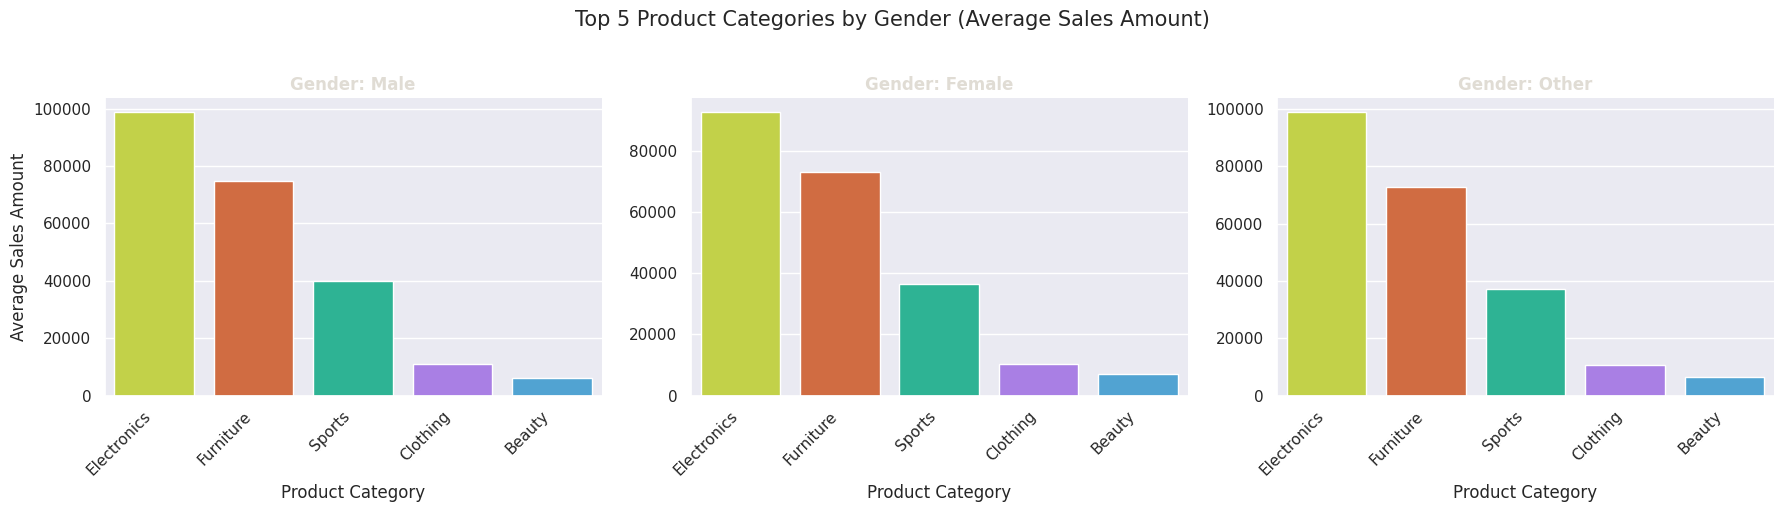

In [64]:
# Calculate the average sales amount for each product category per gender
gender_product_avg_sales = df.groupby(['gender', 'product_category'])['sales_amount'].mean().reset_index(name='average_sales')

# Get the top 5 product categories for each gender based on average sales
top_5_avg_sales_by_gender = gender_product_avg_sales.groupby('gender', group_keys=False).apply(lambda x: x.nlargest(5, 'average_sales')).reset_index(drop=True)

# Map gender numerical labels to descriptive names for plotting
gender_labels = {1: 'Male', 2: 'Female', 3: 'Other'}
top_5_avg_sales_by_gender['gender_label'] = top_5_avg_sales_by_gender['gender'].map(gender_labels)

print("Top 5 Product Categories by Gender (Average Sales Amount):")
display(top_5_avg_sales_by_gender)

sns.set_theme(style="darkgrid") # Ensure dark theme is applied for seaborn plots

# Create a FacetGrid for plotting the top 5 product categories by gender based on average sales
g = sns.catplot(
    data=top_5_avg_sales_by_gender,
    x='product_category',
    y='average_sales',
    col='gender_label', # Create separate columns for each gender
    kind='bar',
    col_wrap=3, # Wrap columns after 3 plots
    height=5,
    aspect=1.2,
    palette=ACCENT,
    sharey=False, # Allow y-axis to scale independently for better visualization
    legend=False # Legend not needed as hue is implicit per column
)

# Set labels and title
g.set_axis_labels("Product Category", "Average Sales Amount")
g.set_titles("Gender: {col_name}")
g.set_xticklabels(rotation=45, ha='right')
g.fig.suptitle('Top 5 Product Categories by Gender (Average Sales Amount)', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()

Order wise different product_category dominates but expenditure wise different porduct_category dominates

We can next check for region wise total number of orders

Step 1: We will plot and check

Value counts for 'region':


,count
region,
W,869
S,860
N,840
E,821
C,779


/tmp/ipykernel_1797/1861851405.py:6: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.countplot(x=df['region'], hue=df['region'], palette=ACCENT, legend=False)


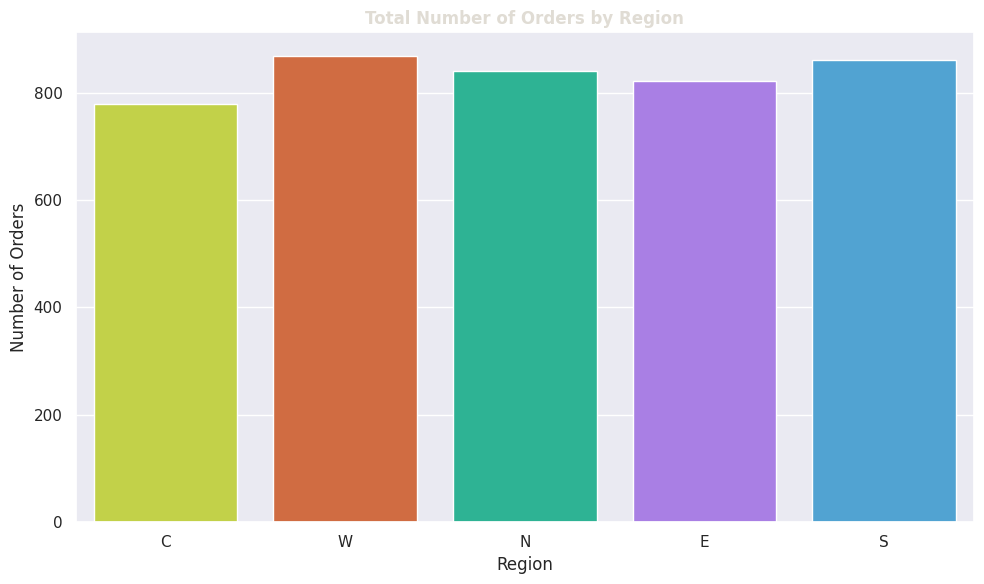

In [65]:
print("Value counts for 'region':")
display(df['region'].value_counts(dropna = False))

sns.set_theme(style="darkgrid") # Ensure dark theme is applied for seaborn plots
plt.figure(figsize=(10, 6))
sns.countplot(x=df['region'], hue=df['region'], palette=ACCENT, legend=False)
plt.title('Total Number of Orders by Region')
plt.xlabel('Region')
plt.ylabel('Number of Orders')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Similarly, we can plot for region vs avg sales

Average sales amount by region:


,sales_amount
region,
E,33781.819421
N,33510.140048
S,33282.676064
W,33050.054203
C,30762.098623


/tmp/ipykernel_1797/1890503991.py:11: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.barplot(x=avg_sales_by_region.index, y=avg_sales_by_region.values, hue=avg_sales_by_region.index, palette=ACCENT, legend=False)


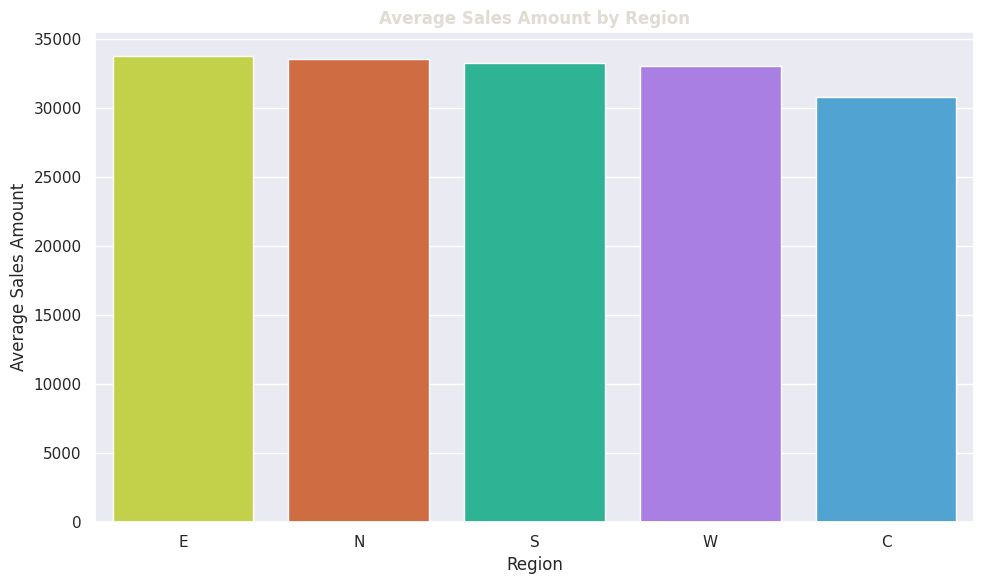

In [66]:
# Calculate the average sales amount per region
avg_sales_by_region = df.groupby('region')['sales_amount'].mean().sort_values(ascending=False)

print("Average sales amount by region:")
display(avg_sales_by_region)

sns.set_theme(style="darkgrid") # Ensure dark theme is applied for seaborn plots
plt.figure(figsize=(10, 6))

# Create the bar plot for average sales amount by region
sns.barplot(x=avg_sales_by_region.index, y=avg_sales_by_region.values, hue=avg_sales_by_region.index, palette=ACCENT, legend=False)

plt.title('Average Sales Amount by Region')
plt.xlabel('Region')
plt.ylabel('Average Sales Amount')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

West and South regions has most number of orders, while East, North, South and West has more avg sales

Next, we can check for product_category and avg profit

Step 1: Plot product_category vs avg profit

Average Profit by Product Category:


,profit
product_category,
Furniture,16966.641526
Electronics,16791.340648
Sports,8206.729052
Clothing,3762.545990
Beauty,2918.286338
Books,1654.133214
Groceries,114.909073


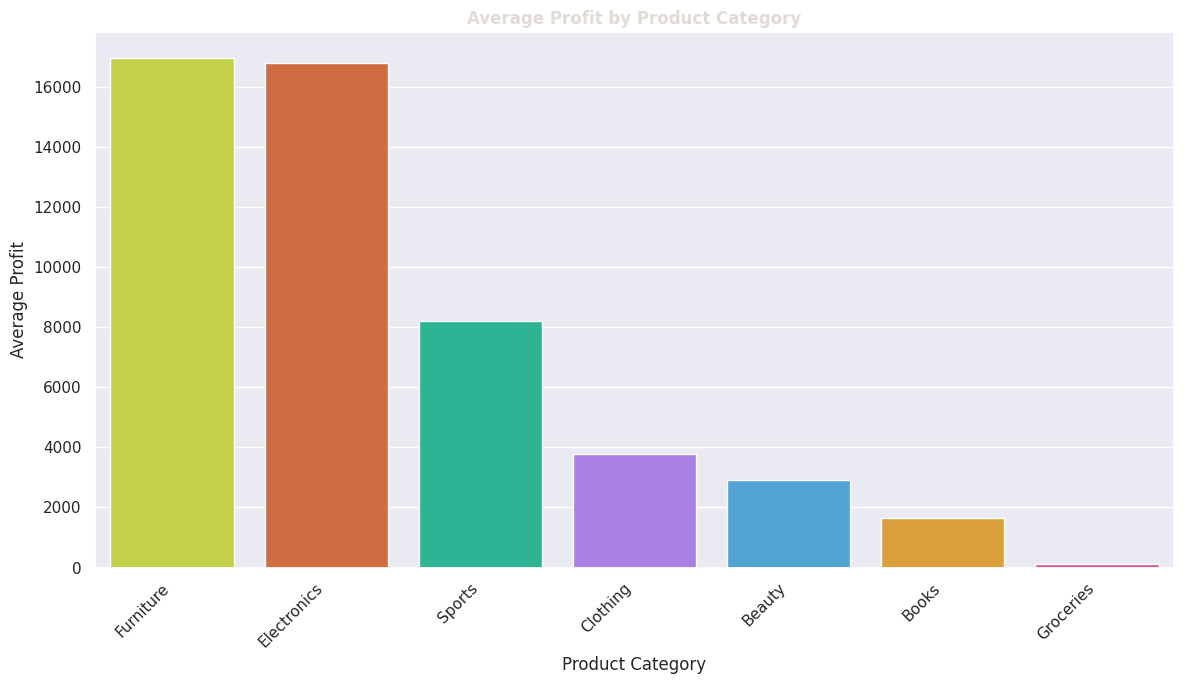

In [67]:
avg_profit_by_category = df.groupby('product_category')['profit'].mean().sort_values(ascending=False)

print("Average Profit by Product Category:")
display(avg_profit_by_category)

sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 7))

sns.barplot(x=avg_profit_by_category.index, y=avg_profit_by_category.values, hue=avg_profit_by_category.index, palette=ACCENT, legend=False)

plt.title('Average Profit by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Electronics and furniture are two product_category with most profits

We can see avg profit according to the region

Step 1: Plotting region vs avg profit

Average Profit by Region:


,profit
region,
S,7342.503599
W,7317.290662
N,7289.852857
E,7211.723069
C,6643.847882


/tmp/ipykernel_1797/2904144196.py:11: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.barplot(x=avg_profit_by_region.index, y=avg_profit_by_region.values, hue=avg_profit_by_region.index, palette=ACCENT, legend=False)


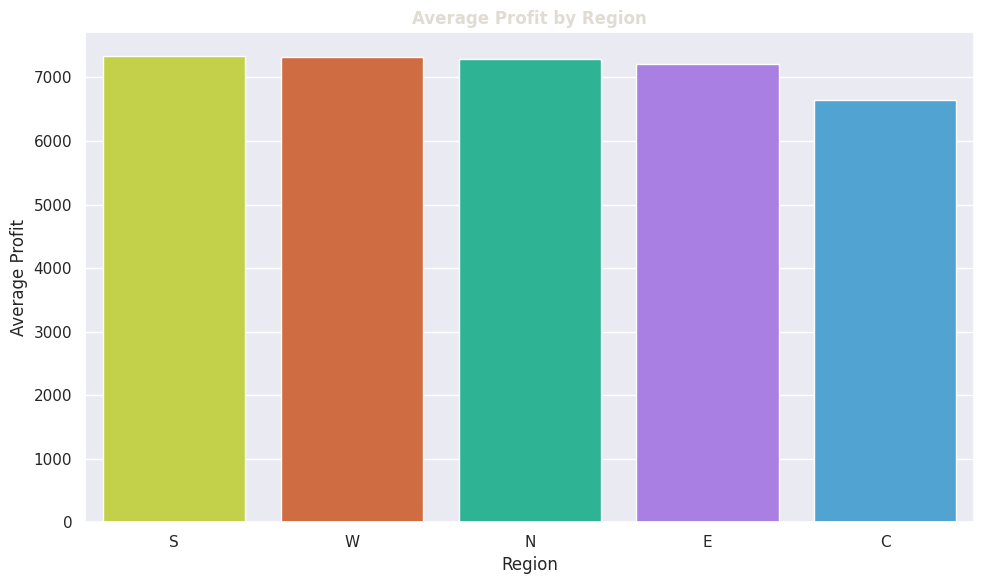

In [68]:
# Calculate the average profit per region
avg_profit_by_region = df.groupby('region')['profit'].mean().sort_values(ascending=False)

print("Average Profit by Region:")
display(avg_profit_by_region)

sns.set_theme(style="darkgrid") # Ensure dark theme is applied for seaborn plots
plt.figure(figsize=(10, 6))

# Create the bar plot for average profit by region
sns.barplot(x=avg_profit_by_region.index, y=avg_profit_by_region.values, hue=avg_profit_by_region.index, palette=ACCENT, legend=False)

plt.title('Average Profit by Region')
plt.xlabel('Region')
plt.ylabel('Average Profit')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Equal amounts of profit in all regions

We can also check for avg profits based on city

Step 1: Plot city vs avg profit

Average Profit by City:


,profit
city,
Chennai,8194.772215
Delhi,7985.835077
Bhopal,7735.903526
Ahmedabad,7692.505924
Hyderabad,7618.911159
Kolkata,7549.006256
Guwahati,7530.294123
Amritsar,7311.874805
Mumbai,7298.839624


/tmp/ipykernel_1797/2592390840.py:11: UserWarning: 
The palette list has fewer values (7) than needed (20) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=avg_profit_by_city.index, y=avg_profit_by_city.values, hue=avg_profit_by_city.index, palette=ACCENT, legend=False)


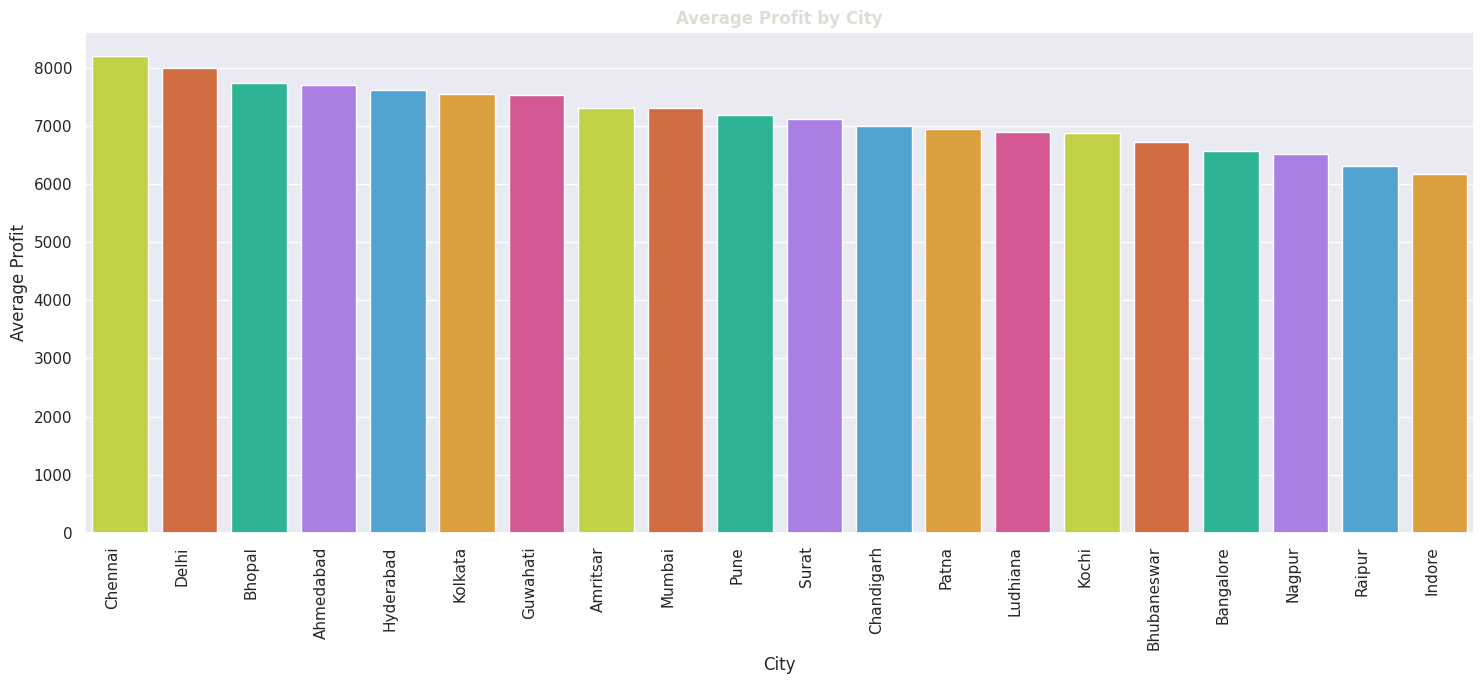

In [69]:
# Calculate the average profit per city
avg_profit_by_city = df.groupby('city')['profit'].mean().sort_values(ascending=False)

print("Average Profit by City:")
display(avg_profit_by_city)

sns.set_theme(style="darkgrid") # Ensure dark theme is applied for seaborn plots
plt.figure(figsize=(15, 7))

# Create the bar plot for average profit by city
sns.barplot(x=avg_profit_by_city.index, y=avg_profit_by_city.values, hue=avg_profit_by_city.index, palette=ACCENT, legend=False)

plt.title('Average Profit by City')
plt.xlabel('City')
plt.ylabel('Average Profit')
plt.xticks(rotation=90, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Profit wise Chennai has the highest followed by other cities

We can next check for the shipping cost wrt region

Step 1: Plot region vs shipping_cost

Average Shipping Cost by Region:


,shipping_cost
region,
E,79.966833
S,69.888407
W,59.870253
C,55.346842
N,51.464429


/tmp/ipykernel_1797/2948988421.py:11: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.barplot(x=avg_shipping_cost_by_region.index, y=avg_shipping_cost_by_region.values, hue=avg_shipping_cost_by_region.index, palette=ACCENT, legend=False)


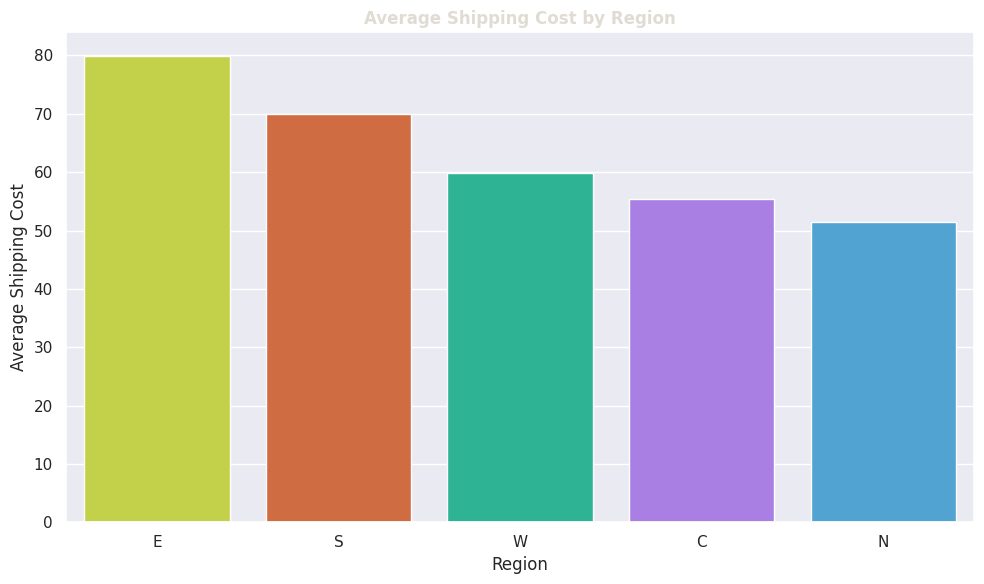

In [70]:
# Calculate the average shipping cost per region
avg_shipping_cost_by_region = df.groupby('region')['shipping_cost'].mean().sort_values(ascending=False)

print("Average Shipping Cost by Region:")
display(avg_shipping_cost_by_region)

sns.set_theme(style="darkgrid") # Ensure dark theme is applied for seaborn plots
plt.figure(figsize=(10, 6))

# Create the bar plot for average shipping cost by region
sns.barplot(x=avg_shipping_cost_by_region.index, y=avg_shipping_cost_by_region.values, hue=avg_shipping_cost_by_region.index, palette=ACCENT, legend=False)

plt.title('Average Shipping Cost by Region')
plt.xlabel('Region')
plt.ylabel('Average Shipping Cost')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

East region has the highest avg shipping_cost

Average Sales Amount by Payment Method with Error Bars

/tmp/ipykernel_1797/612091630.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='payment_method', y='sales_amount', data=df, errorbar='ci', palette='viridis', order=avg_sales_by_payment_method.index)


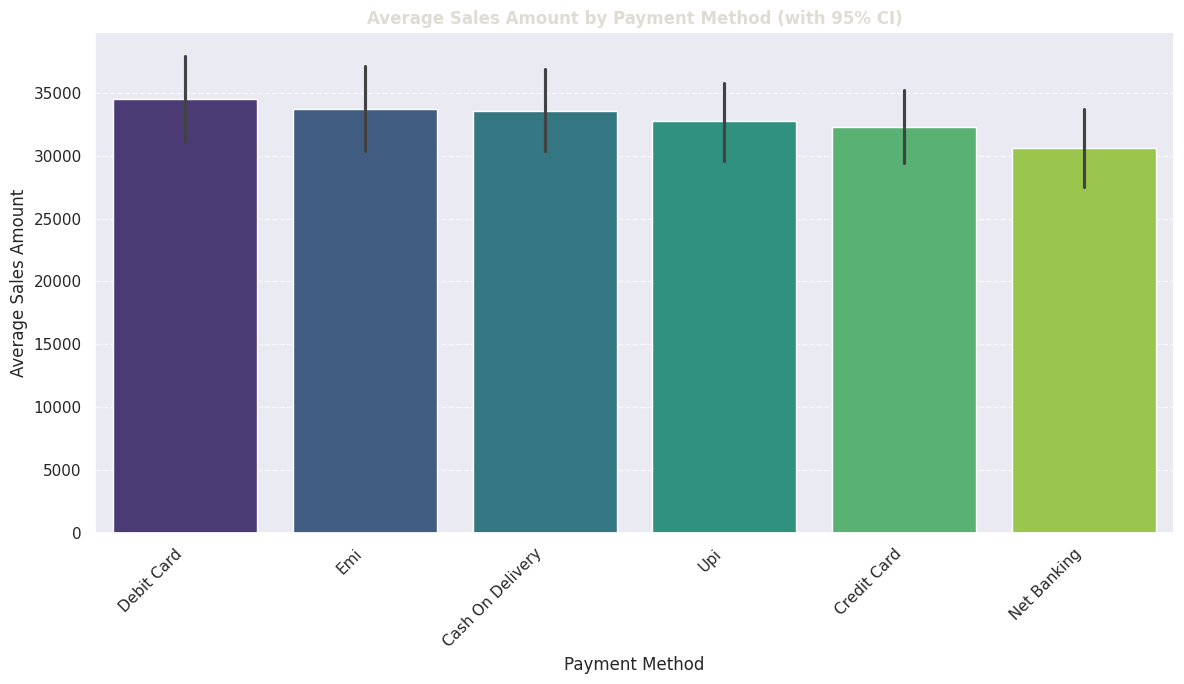


The payment method associated with the highest average sales amount is: Debit Card (34,517.58)


In [71]:
# Calculate average sales_amount per payment_method
avg_sales_by_payment_method = df.groupby('payment_method')['sales_amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='payment_method', y='sales_amount', data=df, errorbar='ci', palette='viridis', order=avg_sales_by_payment_method.index)
plt.title('Average Sales Amount by Payment Method (with 95% CI)')
plt.xlabel('Payment Method')
plt.ylabel('Average Sales Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

highest_sales_payment_method = avg_sales_by_payment_method.index[0]
highest_sales_amount = avg_sales_by_payment_method.iloc[0]

print(f"\nThe payment method associated with the highest average sales amount is: {highest_sales_payment_method} ({highest_sales_amount:,.2f})")

Return rate by product category

In [72]:
# Calculate overall return rate
overall_return_rate = (df['return_flag'].sum() / len(df)) * 100
print(f"Overall Return Rate: {overall_return_rate:.2f}%")

# Calculate return rate by product category
return_rate_by_category = df.groupby('product_category')['return_flag'].sum() / df.groupby('product_category').size() * 100

print("\nReturn Rate by Product Category:")
display(return_rate_by_category.sort_values(ascending=False))

# Identify categories with return rate > 15%
high_return_categories = return_rate_by_category[return_rate_by_category > 15]

if not high_return_categories.empty:
    print("\nProduct Categories with Return Rate > 15%:")
    display(high_return_categories)
else:
    print("\nNo product categories have a return rate greater than 15%.")

Overall Return Rate: 14.61%

Return Rate by Product Category:


,0
product_category,
Electronics,15.946844
Groceries,15.728477
Sports,15.522876
Clothing,13.897764
Beauty,13.879599
Furniture,13.684211
Books,13.464991



Product Categories with Return Rate > 15%:


,0
product_category,
Electronics,15.946844
Groceries,15.728477
Sports,15.522876


/tmp/ipykernel_1797/2817356102.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=return_rate_by_category.index, y=return_rate_by_category.values, palette='viridis')


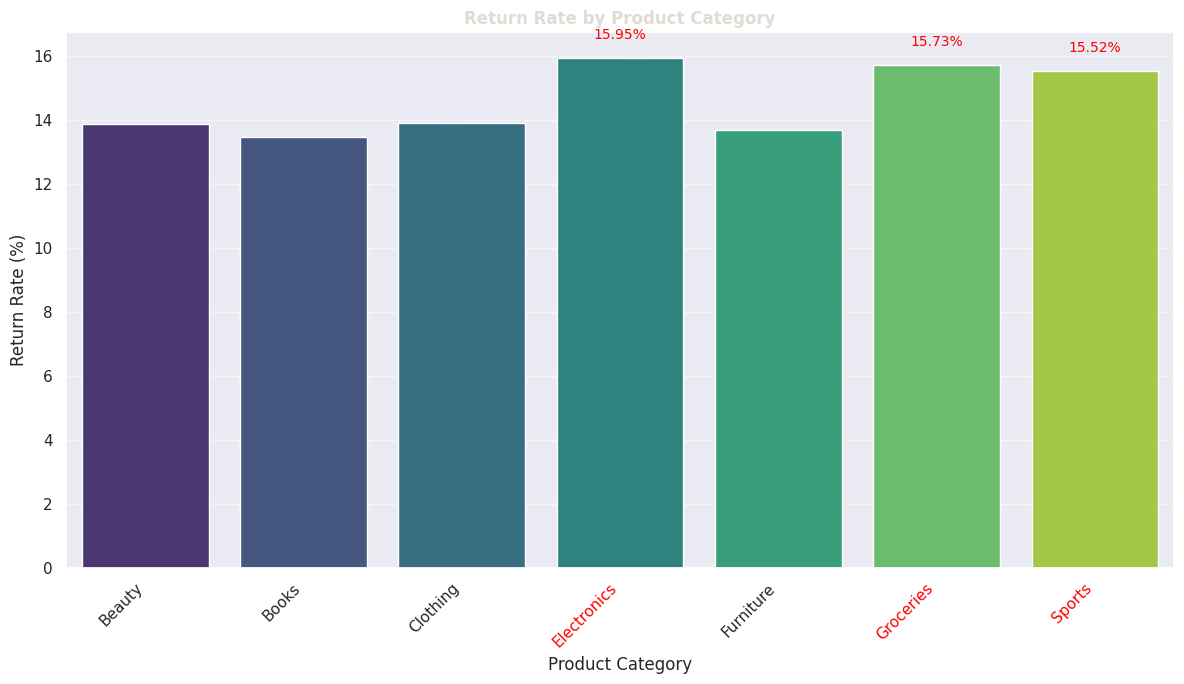

In [73]:
# Plot return rate by product category
plt.figure(figsize=(12, 7))
sns.barplot(x=return_rate_by_category.index, y=return_rate_by_category.values, palette='viridis')
plt.title('Return Rate by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Highlight categories with return rate > 15%
for i, category in enumerate(return_rate_by_category.index):
    if return_rate_by_category[category] > 15:
        plt.gca().get_xticklabels()[i].set_color('red')
        plt.text(i, return_rate_by_category[category] + 0.5,
                 f'{return_rate_by_category[category]:.2f}%',
                 ha='center', va='bottom', color='red', fontsize=10)

plt.tight_layout()
plt.show()

# Multivariate Analysis

Pearson correlation

Step 1: Correlation matrix

In [74]:
# Select only numerical columns for correlation calculation
# Exclude 'order_id' and 'customer_id' as they are identifiers and not meaningful for correlation
numerical_df = df.select_dtypes(include=np.number).drop(columns=['order_id', 'customer_id'], errors='ignore')

# Calculate the Pearson correlation matrix
correlation_matrix = numerical_df.corr(method='pearson')

print("Pearson Correlation Matrix:")
display(correlation_matrix)


Pearson Correlation Matrix:


,age,gender,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,customer_satisfaction,return_flag,days_to_ship
age,1.000000,0.027890,-0.003536,-0.031597,0.005649,-0.008867,-0.012912,-0.018006,-0.019670,-0.012917,0.015067
gender,0.027890,1.000000,-0.020609,0.027396,-0.005862,0.010889,0.006876,-0.003057,0.022174,0.008235,0.001396
quantity,-0.003536,-0.020609,1.000000,0.031531,0.020961,0.276721,0.333127,-0.006431,-0.014938,0.004133,-0.007815
unit_price,-0.031597,0.027396,0.031531,1.000000,-0.018864,0.811981,0.740859,0.011240,-0.014400,-0.005359,0.012887
discount_pct,0.005649,-0.005862,0.020961,-0.018864,1.000000,-0.064143,-0.075119,-0.012366,-0.007529,0.030028,0.002961
sales_amount,-0.008867,0.010889,0.276721,0.811981,-0.064143,1.000000,0.955035,0.013370,-0.019998,-0.000111,0.015819
profit,-0.012912,0.006876,0.333127,0.740859,-0.075119,0.955035,1.000000,0.005693,-0.015261,-0.008173,0.007834
shipping_cost,-0.018006,-0.003057,-0.006431,0.011240,-0.012366,0.013370,0.005693,1.000000,0.010656,-0.005257,0.007848
customer_satisfaction,-0.019670,0.022174,-0.014938,-0.014400,-0.007529,-0.019998,-0.015261,0.010656,1.000000,-0.153248,-0.011995
return_flag,-0.012917,0.008235,0.004133,-0.005359,0.030028,-0.000111,-0.008173,-0.005257,-0.153248,1.000000,0.020984


Step 2: Heatmap for better visualisation

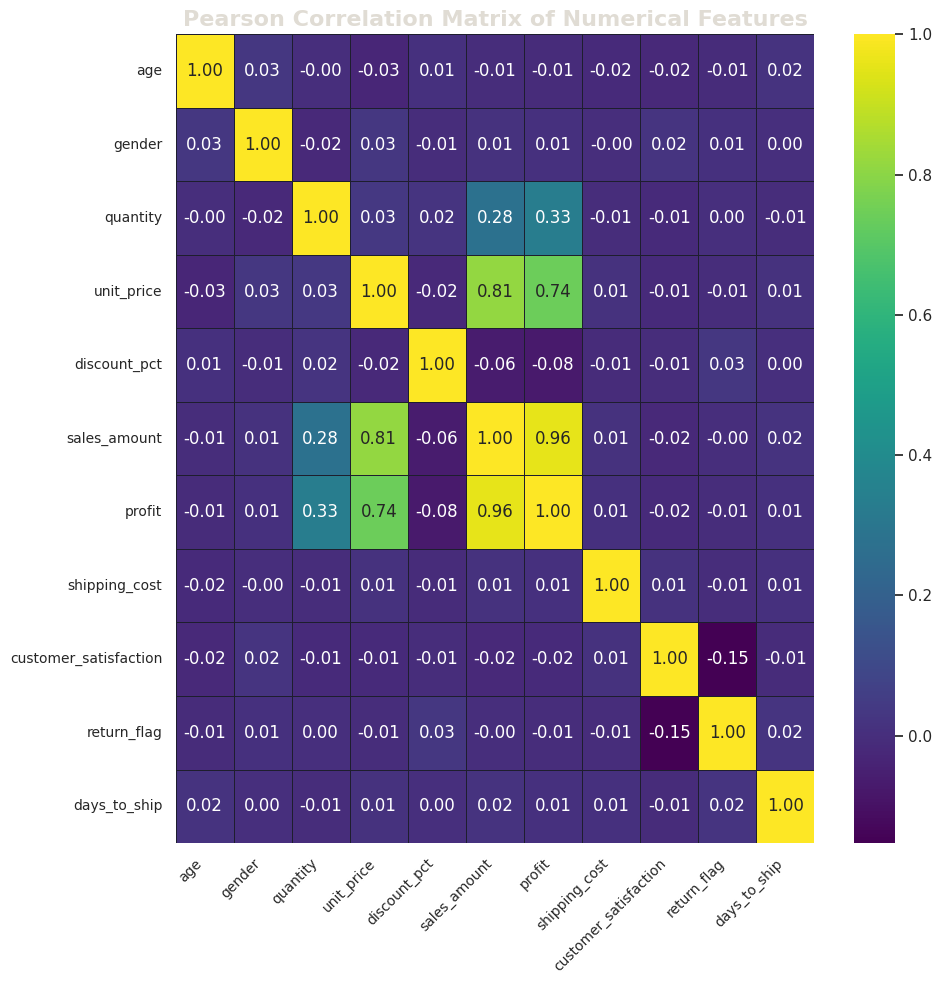

In [75]:
sns.set_theme(style="darkgrid") # Ensure dark theme is applied for seaborn plots
plt.figure(figsize=(10, 10)) # Adjust figure size for better readability of the heatmap

# Create the heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,      # Show the correlation values on the heatmap
    cmap='viridis',  # Choose a color map suitable for dark theme (or try 'rocket', 'mako')
    fmt=".2f",       # Format annotations to two decimal places
    linewidths=.5,   # Add lines between cells
    linecolor='#1e1e2e' # Match line color to grid color for consistency
)

plt.title('Pearson Correlation Matrix of Numerical Features', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Next, we can visualise pairplot

<Figure size 1500x1200 with 0 Axes>

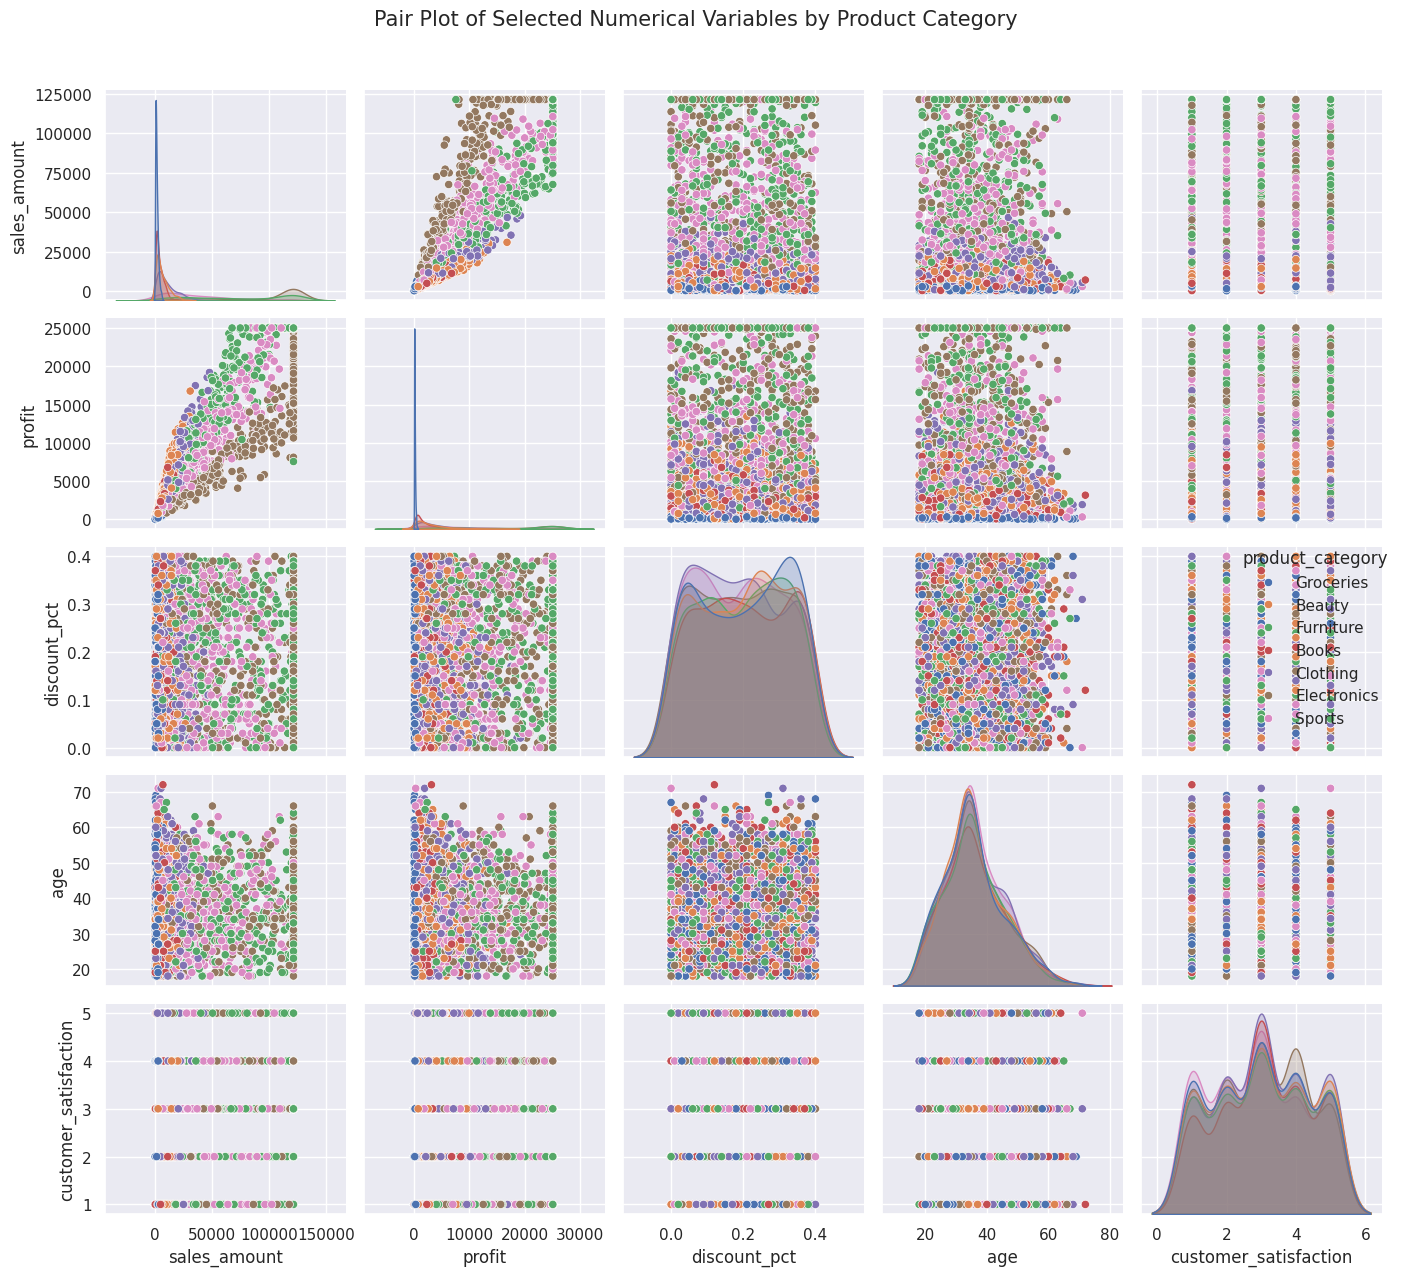

In [76]:
cols_for_pairplot = ['sales_amount', 'profit', 'discount_pct', 'age', 'customer_satisfaction', 'product_category']

plt.figure(figsize=(15, 12))
sns.pairplot(df[cols_for_pairplot], hue="product_category", diag_kind="kde")
plt.suptitle('Pair Plot of Selected Numerical Variables by Product Category', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()

Average days_to_ship per year and region

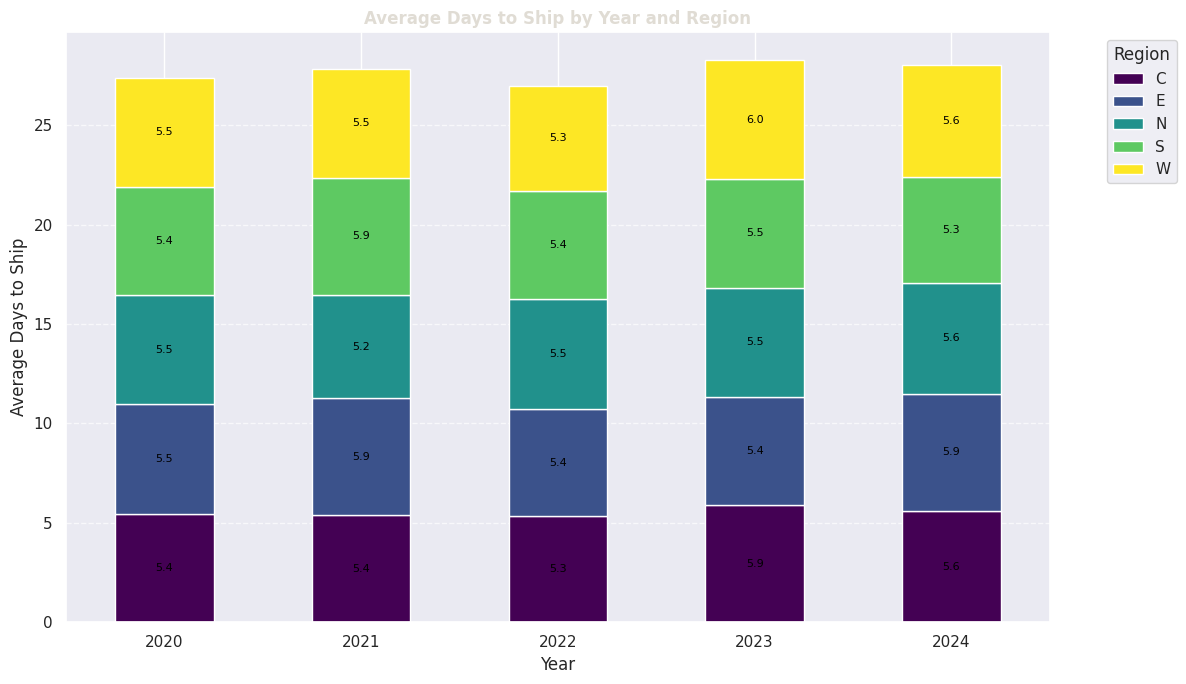


--- Analysis of Shipping Speed Improvement ---
Shipping speed in C appears to be worsening (average days to ship increased from 5.44 to 5.61).
Shipping speed in E appears to be worsening (average days to ship increased from 5.51 to 5.86).
Shipping speed in N appears to be worsening (average days to ship increased from 5.50 to 5.61).
Shipping speed in S appears to be improving (average days to ship decreased from 5.44 to 5.32).
Shipping speed in W appears to be worsening (average days to ship increased from 5.49 to 5.61).


In [91]:
df['order_year'] = df['order_date'].dt.year

avg_days_to_ship_yearly_region = df.groupby(['order_year', 'region'])['days_to_ship'].mean().unstack()

plt.figure(figsize=(12, 7))
ax = plt.gca()
avg_days_to_ship_yearly_region.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
plt.title('Average Days to Ship by Year and Region')
plt.xlabel('Year')
plt.ylabel('Average Days to Ship')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')

# Annotate each segment with its average days to ship
for container in ax.containers:
    labels = [f'{v.get_height():.1f}' if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8, color='black')

plt.tight_layout()
plt.show()

# Analyze if shipping speed is improving
print("\n--- Analysis of Shipping Speed Improvement ---")
for region in avg_days_to_ship_yearly_region.columns:
    regional_trend = avg_days_to_ship_yearly_region[region]
    if len(regional_trend) > 1:
        first_year_avg = regional_trend.iloc[0]
        last_year_avg = regional_trend.iloc[-1]
        if last_year_avg < first_year_avg:
            print(f"Shipping speed in {region} appears to be improving (average days to ship decreased from {first_year_avg:.2f} to {last_year_avg:.2f}).")
        elif last_year_avg > first_year_avg:
            print(f"Shipping speed in {region} appears to be worsening (average days to ship increased from {first_year_avg:.2f} to {last_year_avg:.2f}).")
        else:
            print(f"Shipping speed in {region} shows no significant change (average days to ship remained around {first_year_avg:.2f}).")
    else:
        print(f"Not enough data to determine shipping speed improvement for {region}.")

# Time series and trend analysis

Monthly sales amount with 3-month rolling mean

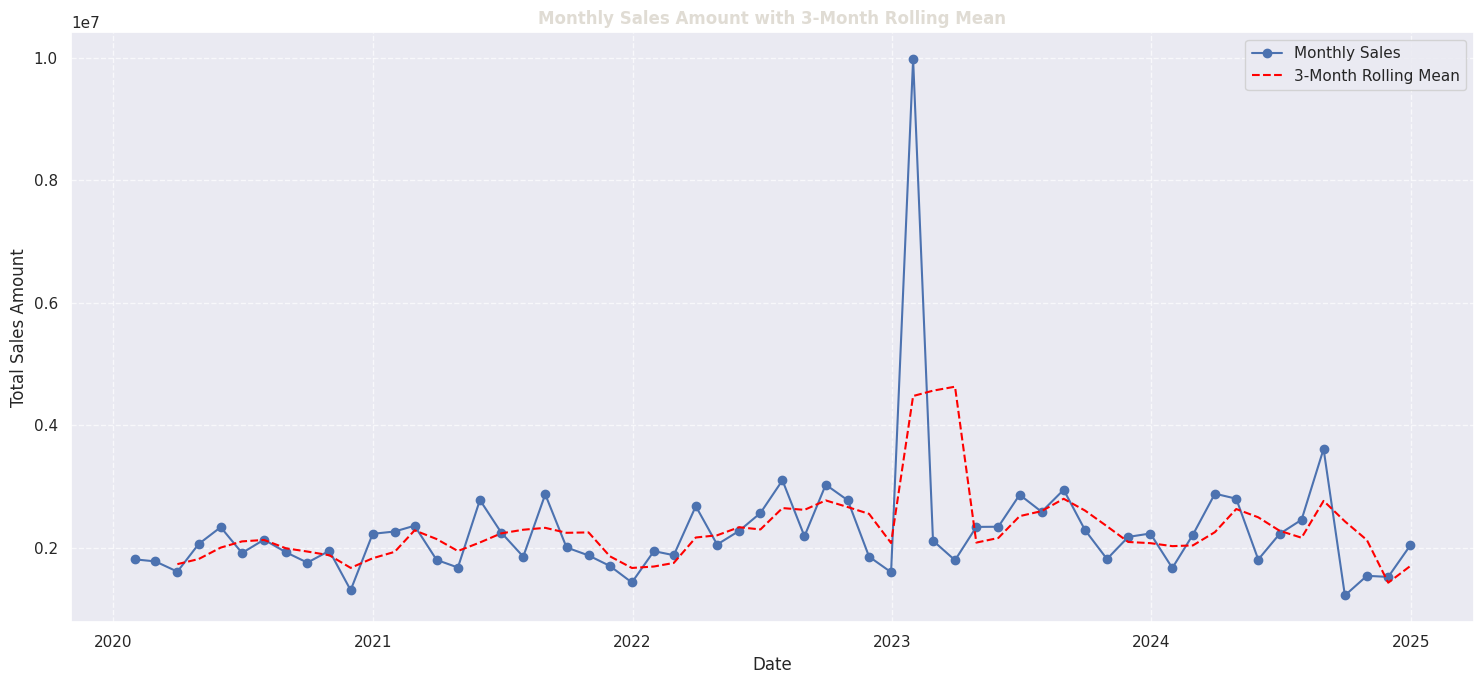


--- Trend Analysis ---
There appears to be an overall upward trend in sales.

--- Q4 Peak Analysis ---
Sales in Q4 (Oct-Dec) tend to be:
order_date
2020-10-31    1.951940e+06
2020-11-30    1.309390e+06
2020-12-31    2.228649e+06
2021-10-31    1.876081e+06
2021-11-30    1.704448e+06
2021-12-31    1.434855e+06
2022-10-31    2.776044e+06
2022-11-30    1.856071e+06
2022-12-31    1.602172e+06
2023-10-31    1.817345e+06
2023-11-30    2.178535e+06
2023-12-31    2.234018e+06
2024-10-31    1.543810e+06
2024-11-30    1.525800e+06
2024-12-31    2.039077e+06
Name: sales_amount, dtype: float64
Q4 sales do not appear to consistently peak significantly above average.


In [78]:
# Convert 'order_date' to datetime and set as index
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed')
df_time_series = df.set_index('order_date')

# Resample sales_amount monthly and sum
monthly_sales = df_time_series['sales_amount'].resample('ME').sum()

# Calculate 3-month rolling mean
rolling_mean = monthly_sales.rolling(window=3).mean()

# Plot monthly sales and rolling mean
plt.figure(figsize=(15, 7))
plt.plot(monthly_sales.index, monthly_sales.values, label='Monthly Sales', marker='o', linestyle='-')
plt.plot(rolling_mean.index, rolling_mean.values, label='3-Month Rolling Mean', color='red', linestyle='--')

plt.title('Monthly Sales Amount with 3-Month Rolling Mean')
plt.xlabel('Date')
plt.ylabel('Total Sales Amount')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Analyze trends
print("\n--- Trend Analysis ---")
if monthly_sales.iloc[-1] > monthly_sales.iloc[0]:
    print("There appears to be an overall upward trend in sales.")
else:
    print("There does not appear to be an overall upward trend in sales.")

# Check for Q4 peaks (October, November, December)
q4_sales = monthly_sales[(monthly_sales.index.month >= 10) & (monthly_sales.index.month <= 12)]
if not q4_sales.empty:
    print("\n--- Q4 Peak Analysis ---")
    print("Sales in Q4 (Oct-Dec) tend to be:")
    print(q4_sales)
    # You can add more detailed analysis here, e.g., comparison to other quarters
    # For simplicity, just check if Q4 sales are generally higher than average
    avg_monthly_sales = monthly_sales.mean()
    if q4_sales.mean() > avg_monthly_sales:
        print(f"Q4 sales ({q4_sales.mean():.2f}) are generally higher than the overall average monthly sales ({avg_monthly_sales:.2f}).")
    else:
        print("Q4 sales do not appear to consistently peak significantly above average.")
else:
    print("No Q4 data available in the dataset for peak analysis.")

Monthly sales comparison by year

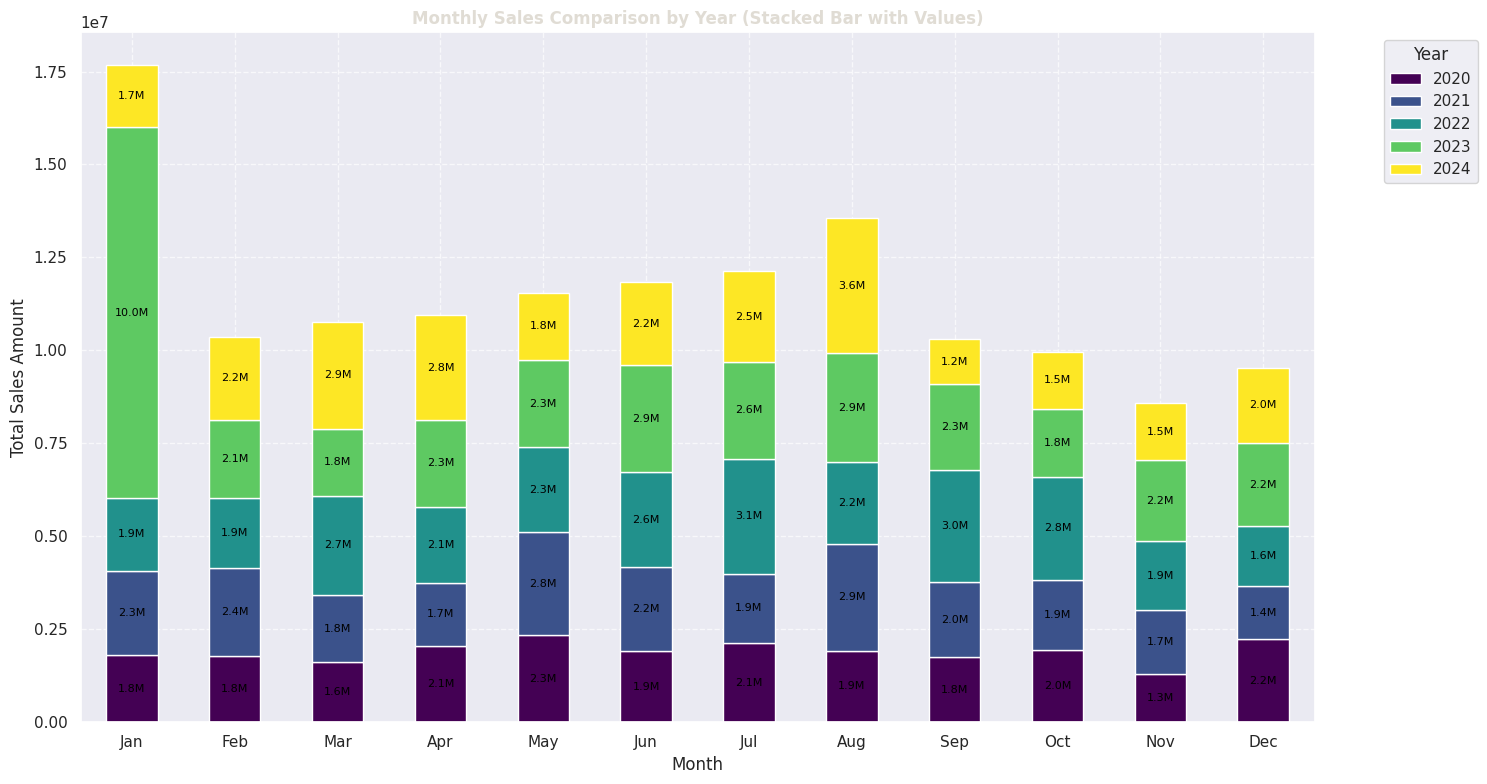


The year with the highest single monthly sales peak is: 2023 with a sales amount of 9973562.66


In [90]:
# Prepare data for yearly comparison
yearly_monthly_sales = monthly_sales.reset_index()
yearly_monthly_sales['year'] = yearly_monthly_sales['order_date'].dt.year
yearly_monthly_sales['month'] = yearly_monthly_sales['order_date'].dt.month

# Create a pivot table for easier plotting, filling NaN values with 0
pivoted_sales = yearly_monthly_sales.pivot_table(index='month', columns='year', values='sales_amount', fill_value=0)

# Plotting
fig, ax = plt.subplots(figsize=(15, 8))
# Create the stacked bar chart
pivoted_sales.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')

plt.title('Monthly Sales Comparison by Year (Stacked Bar with Values)')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
# Set x-axis ticks and labels for months
ax.set_xticks(range(len(pivoted_sales.index)))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=0)
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Annotate each segment with its sales amount
for container in ax.containers:
    labels = []
    for rect in container:
        height = rect.get_height()
        if height > 0: # Only label non-zero segments
            # Format large numbers for better readability
            if height >= 1_000_000:
                labels.append(f'{height/1_000_000:.1f}M')
            elif height >= 1_000:
                labels.append(f'{height/1_000:.0f}K') # Use 0 decimal for K if values are integers
            else:
                labels.append(f'{height:.0f}')
        else:
            labels.append('')
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8, color='black')

plt.tight_layout()
plt.show()

# Identify the year with the highest single monthly sales peak
highest_peak_year = pivoted_sales.max().idxmax()
highest_peak_value = pivoted_sales.max().max()

print(f"\nThe year with the highest single monthly sales peak is: {int(highest_peak_year)} with a sales amount of {highest_peak_value:.2f}")

Quarterly sales by product category

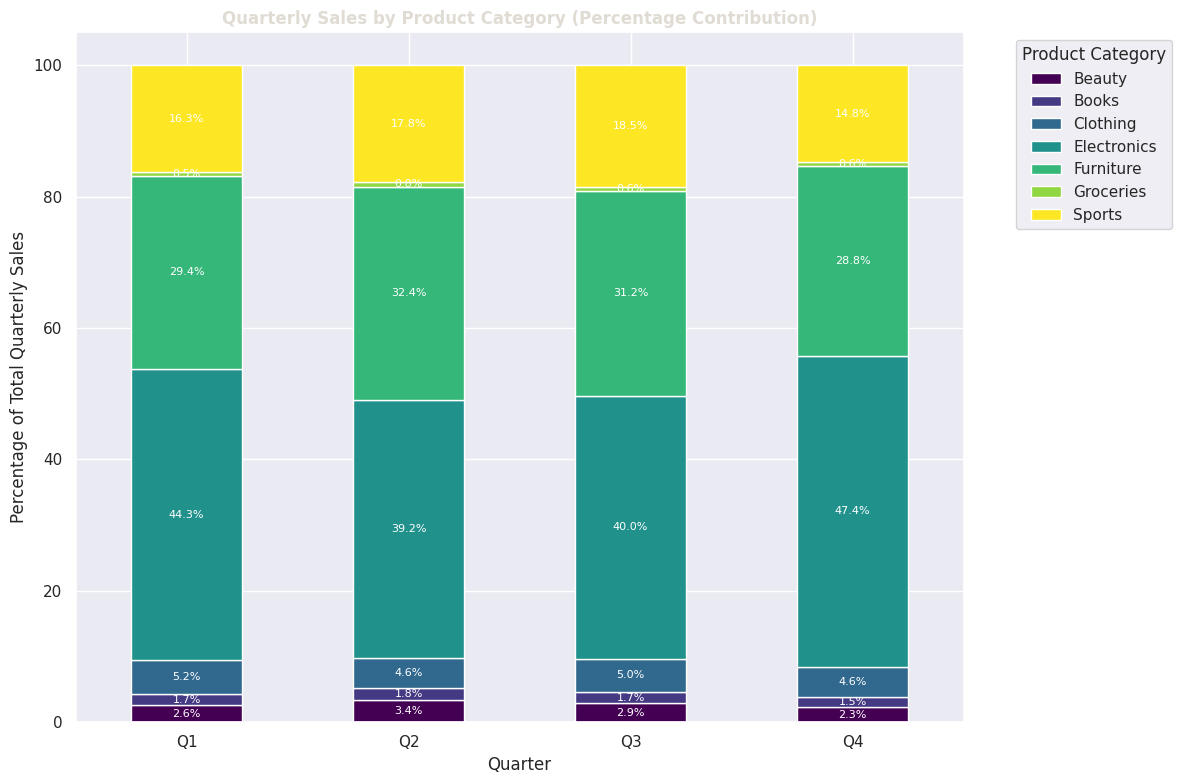

In [80]:
# Extract quarter from order_date
df['quarter'] = df['order_date'].dt.quarter

# Group by quarter and product_category to get total sales
quarterly_sales_by_category = df.groupby(['quarter', 'product_category'])['sales_amount'].sum().unstack(fill_value=0)

# Calculate percentage contribution for each category within each quarter
quarterly_sales_percentage = quarterly_sales_by_category.apply(lambda x: x / x.sum() * 100, axis=1)

# Plotting the stacked bar chart
fig, ax = plt.subplots(figsize=(12, 8))
quarterly_sales_percentage.plot(kind='bar', stacked=True, colormap='viridis', ax=ax)

# Add labels and title
ax.set_title('Quarterly Sales by Product Category (Percentage Contribution)')
ax.set_xlabel('Quarter')
ax.set_ylabel('Percentage of Total Quarterly Sales')
ax.set_xticks(range(len(quarterly_sales_percentage.index)))
ax.set_xticklabels([f'Q{q}' for q in quarterly_sales_percentage.index], rotation=0)
ax.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')

# Annotate each segment with its percentage contribution
for container in ax.containers:
    labels = [f'{w:.1f}%' if (w := v.get_height()) > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8, color='white')

plt.tight_layout()
plt.show()

Month over month sales growth

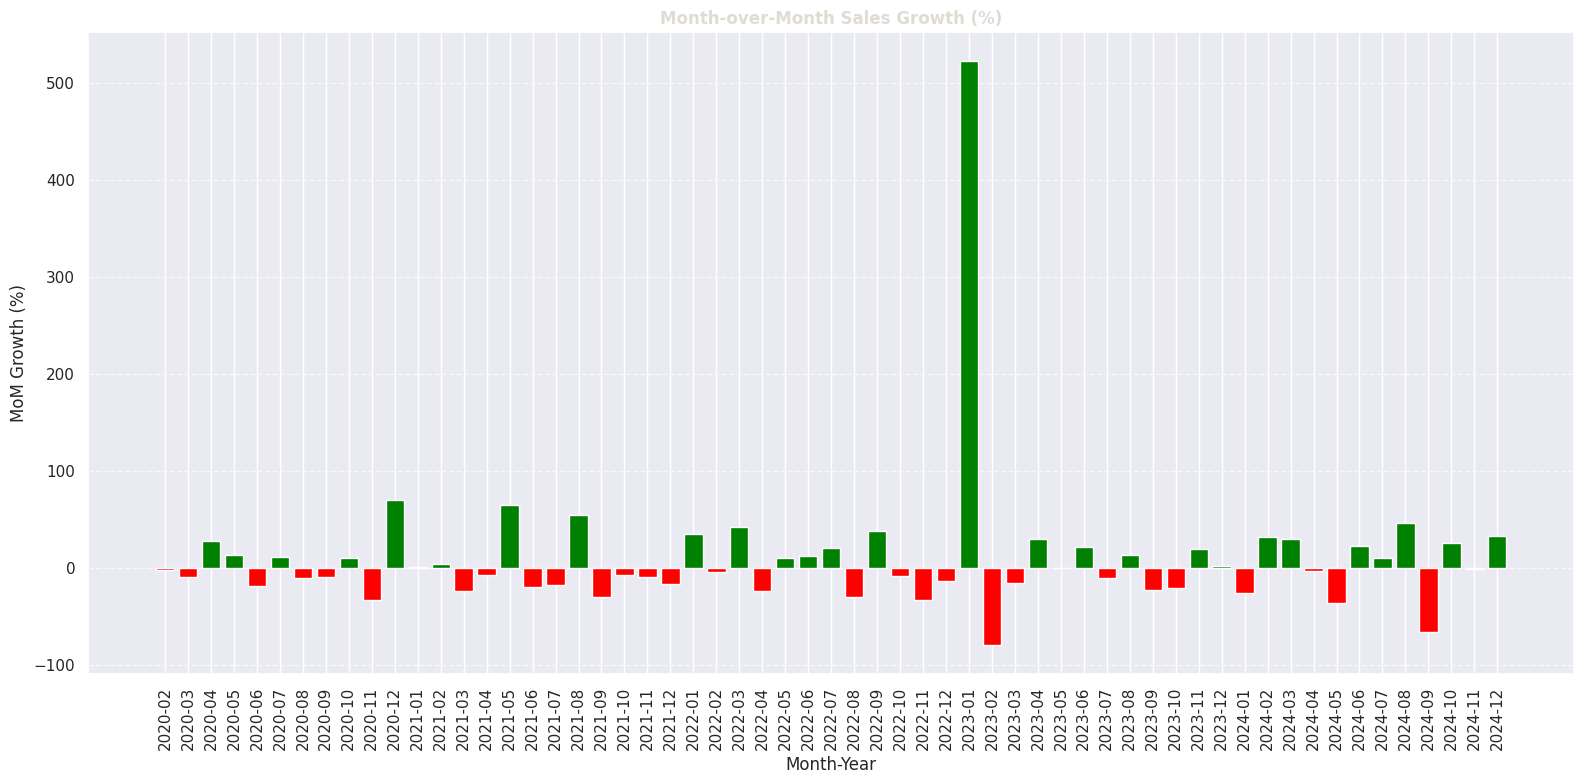


Top 3 Months with Highest Month-over-Month Growth:
  2023-01: 522.50%
  2020-12: 70.21%
  2021-05: 65.61%


In [92]:
# Calculate Month-over-Month growth
monthly_growth = monthly_sales.pct_change() * 100

# Drop the first NaN value as there's no previous month to compare to
monthly_growth = monthly_growth.dropna()

# Plotting as a diverging bar chart
plt.figure(figsize=(16, 8))
colors = ['red' if x < 0 else 'green' for x in monthly_growth]
plt.bar(monthly_growth.index.strftime('%Y-%m'), monthly_growth.values, color=colors)

plt.title('Month-over-Month Sales Growth (%)')
plt.xlabel('Month-Year')
plt.ylabel('MoM Growth (%)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Identify the top 3 months with the highest MoM growth
top_3_growth_months = monthly_growth.nlargest(3)
print("\nTop 3 Months with Highest Month-over-Month Growth:")
for month, growth in top_3_growth_months.items():
    print(f"  {month.strftime('%Y-%m')}: {growth:.2f}%")